<a href="https://colab.research.google.com/github/alessandroamds/MODELAGEM_PREDITIVA_DO_RISCO_DE_CREDITO_COM_MACHINE_LEARNING_EM_OPERACOES_CAPITAL_DE_GIRO_E_PRONAMPE/blob/main/Artigo_MODELAGEM_PREDITIVA_DO_RISCO_DE_CR%C3%89DITO_COM_MACHINE_LEARNING_EM_OPERA%C3%87%C3%95ES_DE_CAPITAL_DE_GIRO_E_PRONAMPE_v22042026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ====================================================================================================================
# Artigo: MODELAGEM PREDITIVA DO RISCO DE CRÉDITO COM MACHINE LEARNING EM OPERAÇÕES DE CAPITAL DE GIRO E PRONAMPE
# ====================================================================================================================

# ============================================================
# [ETAPA 0.1 / 0.2] Configuração do Ambiente de Execução
# Objetivo: importar bibliotecas, montar Drive, definir caminhos,
#           fixar parâmetros globais e cortes temporais.
# ============================================================

import os, gc, time, warnings, math, joblib
import numpy as np
import pandas as pd
from datetime import datetime

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# XGBoost
from xgboost import XGBClassifier

# Métricas e testes estatísticos
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score,
    precision_score, accuracy_score
)
from scipy.stats import ks_2samp, wilcoxon, mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
from google.colab import drive

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# ============================================================
# 🔷 INÍCIO DA ETAPA 0.1 / 0.2
# ============================================================
print("\n" + "═"*90)
print("🔷  ETAPA 0.1 / 0.2 — CONFIGURAÇÃO DO AMBIENTE")
print("═"*90)

# ------------------------------------------------------------
# 📂 Montagem do Google Drive
# ------------------------------------------------------------
print("\n📂 Montando Google Drive...")
drive.mount("/content/drive")
print("   ✅ Drive montado com sucesso!")

# ------------------------------------------------------------
# 📁 Definição de diretórios e arquivos
# ------------------------------------------------------------
BASE_PATH = "/content/drive/MyDrive/Artigo_MODELAGEM PREDITIVA DO RISCO DE CRÉDITO COM MACHINE LEARNING EM OPERAÇÕES DE CAPITAL DE GIRO E PRONAMPE"
FILE_CG = "base_capitalgiro.parquet"
FILE_PRONAMPE = "base_pronampe.parquet"

MODEL_SAVE_DIR = os.path.join(BASE_PATH, "Resultados_Artigo_MODELAGEM PREDITIVA DO RISCO DE CRÉDITO COM MACHINE LEARNING EM OPERAÇÕES DE CAPITAL DE GIRO E PRONAMPE")
SHAP_SAVE_DIR  = os.path.join(MODEL_SAVE_DIR, "shap_outputs")

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(SHAP_SAVE_DIR, exist_ok=True)

print("\n📁 Diretórios configurados:")
print(f"   • 🗂️ BASE_PATH.........: {BASE_PATH}")
print(f"   • 📄 FILE_CG...........: {FILE_CG}")
print(f"   • 📄 FILE_PRONAMPE.....: {FILE_PRONAMPE}")
print(f"   • 💾 MODEL_SAVE_DIR....: {MODEL_SAVE_DIR}")
print(f"   • 📊 SHAP_SAVE_DIR.....: {SHAP_SAVE_DIR}")

# ------------------------------------------------------------
# ⚙️ Parâmetros globais da execução
# ------------------------------------------------------------
MODE_RUN = "FAST"   # >> Alterar para "FULL" na execução final
SEED = 42
np.random.seed(SEED)

print("\n⚙️  Parâmetros globais definidos:")
print(f"   • 🔧 Seed................: {SEED}")
print(f"   • 🚀 Modo de execução....: {MODE_RUN}")

if MODE_RUN == "FULL":
    MAX_SAMPLES = 5_000_000
    N_FOLDS = 5
    MAX_SAMPLE_SHAP = 50_000
    print("   • 🧮 MODO COMPLETO ATIVO: Execução final para dissertação")
else:
    print("   • ⚠️ MODO RÁPIDO ATIVO: Amostras e folds reduzidos para testes")
    MAX_SAMPLES = 200_000
    N_FOLDS = 2
    MAX_SAMPLE_SHAP = 10_000

print(f"   • 📊 MAX_SAMPLES.........: {MAX_SAMPLES:,}")
print(f"   • 🔁 N_FOLDS.............: {N_FOLDS}")
print(f"   • 🔍 MAX_SAMPLE_SHAP.....: {MAX_SAMPLE_SHAP:,}")

# ------------------------------------------------------------
# 🕒 Definição dos cortes temporais
# ------------------------------------------------------------
CG_CUTOFF        = pd.Timestamp("2021-12-31")
PRONAMPE_CUTOFF  = pd.Timestamp("2023-12-31")
GLOBAL_CUTOFF    = pd.Timestamp("2021-12-31")

print("\n🕒 Cortes temporais definidos:")
print(f"   • 🟦 CUTOFF CG...........: {CG_CUTOFF.strftime('%Y-%m-%d')}")
print(f"   • 🟧 CUTOFF PRONAMPE.....: {PRONAMPE_CUTOFF.strftime('%Y-%m-%d')}")
print(f"   • 🟩 CUTOFF GLOBAL.......: {GLOBAL_CUTOFF.strftime('%Y-%m-%d')}")


# ------------------------------------------------------------
# ✔️ Finalização da etapa
# ------------------------------------------------------------
print("\n✅ ETAPA 0.1 / 0.2 concluída com sucesso.")
print("═"*90 + "\n")



══════════════════════════════════════════════════════════════════════════════════════════
🔷  ETAPA 0.1 / 0.2 — CONFIGURAÇÃO DO AMBIENTE
══════════════════════════════════════════════════════════════════════════════════════════

📂 Montando Google Drive...
Mounted at /content/drive
   ✅ Drive montado com sucesso!

📁 Diretórios configurados:
   • 🗂️ BASE_PATH.........: /content/drive/MyDrive/Artigo_MODELAGEM PREDITIVA DO RISCO DE CRÉDITO COM MACHINE LEARNING EM OPERAÇÕES DE CAPITAL DE GIRO E PRONAMPE
   • 📄 FILE_CG...........: base_capitalgiro.parquet
   • 📄 FILE_PRONAMPE.....: base_pronampe.parquet
   • 💾 MODEL_SAVE_DIR....: /content/drive/MyDrive/Artigo_MODELAGEM PREDITIVA DO RISCO DE CRÉDITO COM MACHINE LEARNING EM OPERAÇÕES DE CAPITAL DE GIRO E PRONAMPE/Resultados_Artigo_MODELAGEM PREDITIVA DO RISCO DE CRÉDITO COM MACHINE LEARNING EM OPERAÇÕES DE CAPITAL DE GIRO E PRONAMPE
   • 📊 SHAP_SAVE_DIR.....: /content/drive/MyDrive/Artigo_MODELAGEM PREDITIVA DO RISCO DE CRÉDITO COM MACHINE LE

In [ ]:
# ============================================================
# [ETAPA 1.1] Funções utilitárias e de feature engineering
# Objetivo: definir funções auxiliares para otimização de memória,
#           criação da variável-alvo regulatória, amostragem estratificada
#           e métricas de eficiência alocativa (Gini, Lift, decis).
# ============================================================

def optimize_memory(df: pd.DataFrame) -> pd.DataFrame:
    """
    Reduz uso de memória (downcast de tipos numéricos e categorização).
    Mantém identificadores sensíveis ('numero_contrato', 'cpf_cnpj_cong')
    sem downcast para evitar perda de precisão.
    """
    mem_before = df.memory_usage(deep=True).sum() / (1024**2)
    print("\n🧮 [optimize_memory] Otimizando uso de memória do DataFrame...")
    print(f"   • Memória antes da otimização: {mem_before:.2f} MB")

    for col in df.columns:
        col_type = df[col].dtype

        # Downcast de floats
        if "float" in str(col_type):
            df[col] = pd.to_numeric(df[col], downcast="float", errors="ignore")

        # Downcast de inteiros (exceto identificadores)
        elif "int" in str(col_type) and col not in ["numero_contrato", "cpf_cnpj_cong"]:
            df[col] = pd.to_numeric(df[col], downcast="integer", errors="ignore")

        # Conversão para category quando número de categorias é baixo
        if df[col].dtype == "object" and df[col].nunique() < 50:
            df[col] = df[col].astype("category")

    mem_after = df.memory_usage(deep=True).sum() / (1024**2)
    perc_red = (1 - mem_after/mem_before)*100 if mem_before > 0 else 0

    print(f"   • Memória após otimização: {mem_after:.2f} MB")
    print(f"   ✅ Redução estimada de memória: {perc_red:.2f}%")

    return df

def aplica_regras_regulatorias_e_features(df: pd.DataFrame, nome_carteira: str) -> pd.DataFrame:
    """
    Aplica regras regulatórias e cria variáveis derivadas principais:
      - Converte colunas de data
      - Cria alvo binário 'ativo_problematico' (atraso > 90 dias)
      - Inclui indicador de carteira
      - Calcula idade do contrato em dias
    """
    print(f"\n📌 [aplica_regras_regulatorias_e_features] Processando carteira: {nome_carteira}")
    df = df.copy()

    # Conversões de data
    print("   • Convertendo colunas de data para datetime...")
    df["posicao_ano_mes"] = pd.to_datetime(df["posicao_ano_mes"], format="%Y%m", errors="coerce")
    df["data_concessao"] = pd.to_datetime(df["data_concessao"], errors="coerce")
    df["data_primeira_prestacao_nao_paga"] = pd.to_datetime(df["data_primeira_prestacao_nao_paga"], errors="coerce")

    # Alvo binário regulatório: contrato problemático (atraso > 90 dias)
    print("   • Criando variável-alvo regulatória 'ativo_problematico' (atraso > 90 dias)...")
    df["ativo_problematico"] = np.where(df["prazo_atraso_dias"].fillna(0) > 90, 1, 0)

    # Indicador de carteira
    df["carteira_indicadora"] = nome_carteira

    # Variável derivada: idade do contrato (em dias)
    print("   • Calculando 'idade_contrato_dias' (posicao_ano_mes - data_concessao)...")
    df["idade_contrato_dias"] = (df["posicao_ano_mes"] - df["data_concessao"]).dt.days

    # CORREÇÃO CRÍTICA DE LEAKAGE:
    # 'tempo_desde_primeira_inadimplencia' removida para evitar viés temporal.

    print("   ✅ Regras regulatórias e features derivadas aplicadas com sucesso.")
    return df

def amostra_estratificada(
    df: pd.DataFrame,
    max_rows: int,
    target_col: str = "ativo_problematico",
    seed: int = 42
):
    """
    Reduz o tamanho da base de forma controlada (preserva a taxa de inadimplência).
    Utiliza amostragem estratificada com base na variável-alvo.
    """
    print(f"\n🎲 [amostra_estratificada] Iniciando amostragem estratificada (limite = {max_rows:,} linhas)...")
    print(f"   • Tamanho original da base: {len(df):,} linhas")

    if len(df) <= max_rows:
        print("   ℹ️ Base menor ou igual ao limite. Nenhuma amostragem aplicada.")
        return df.copy()

    df_sample, _ = train_test_split(
        df,
        train_size=max_rows,
        shuffle=True,
        stratify=df[target_col],
        random_state=seed
    )

    print(f"   ✅ Amostragem concluída. Tamanho final: {len(df_sample):,} linhas")
    return df_sample.copy()

def calc_gini(y_true, y_score):
    """Cálculo do Gini a partir da AUC: Gini = 2*AUC - 1."""
    auc = roc_auc_score(y_true, y_score)
    return 2 * auc - 1

def calc_lift_at_k(y_true, y_score, k=0.10):
    """
    Calcula o Lift@k (mede eficiência alocativa).
    Compara a taxa de default no top-k% mais arriscado
    com a taxa média da carteira.
    """
    tmp = pd.DataFrame({"y": y_true, "score": y_score}).sort_values("score", ascending=False)
    top_k = int(np.ceil(k * len(tmp)))
    rate_top = tmp.iloc[:top_k]["y"].mean()
    rate_all = tmp["y"].mean()
    return rate_top / rate_all if rate_all > 0 else np.nan

def decile_analysis(y_true, y_score, exposure=None):
    """
    Agrupa observações em decis (10 grupos) com base no score de risco.
    Retorna resumo com:
      - taxa_default
      - quantidade de observações
      - score médio
    """
    tmp = pd.DataFrame({"y": y_true, "score": y_score})
    if exposure is not None:
        tmp["exposure"] = exposure

    tmp["decile"] = pd.qcut(
        tmp["score"].rank(method="first", ascending=False),
        10,
        labels=False
    )

    resumo = tmp.groupby("decile").agg(
        taxa_default=("y", "mean"),
        qtd=("y", "size"),
        score_medio=("score", "mean"),
    )

    return resumo.reset_index()

# ============================================================
# ✅ Confirmação da etapa
# ============================================================
print("\n✅ [ETAPA 1.1] Funções utilitárias, regulatórias e de eficiência alocativa definidas.\n")




✅ [ETAPA 1.1] Funções utilitárias, regulatórias e de eficiência alocativa definidas.



In [ ]:
# ============================================================
# [ETAPA 1.1.1] CHECK METODOLÓGICO — Preservação da taxa de AP
# Objetivo: verificar AP antes e depois da amostragem estratificada
# ============================================================

def resumo_ap(df: pd.DataFrame, nome: str):
    """Resumo simples da taxa de AP (por linha/foto mensal)."""
    ap = df["ativo_problematico"].mean()
    n = len(df)
    n_ap = int(df["ativo_problematico"].sum())
    print(f"   • {nome:<18}: N={n:,} | AP={ap:.4f} | AP_count={n_ap:,}")
    return ap, n, n_ap

def compara_ap(ap_before, ap_after, nome: str, tol_abs=1e-4):
    """
    Compara AP antes e depois da amostragem.
    tol_abs = tolerância absoluta (ex.: 1e-4 = 0,01 p.p.).
    """
    diff_abs = abs(ap_after - ap_before)
    diff_pp = diff_abs * 100  # pontos percentuais
    status = "✅ PRESERVADO" if diff_abs <= tol_abs else "⚠️ VERIFICAR"
    print(f"   • {nome:<18}: AP_before={ap_before:.4f} | AP_after={ap_after:.4f} "
          f"| Δabs={diff_abs:.6f} ({diff_pp:.4f} p.p.) -> {status}")
    return diff_abs


In [ ]:
# ============================================================
# [ETAPA 1.2] Carregamento e pré-processamento das bases
# Objetivo: carregar as bases de Capital de Giro e PRONAMPE,
#           aplicar regras regulatórias e feature engineering,
#           realizar amostragem estratificada e otimizar uso de RAM.
# ============================================================

print("\n" + "═"*90)
print("🏗️  ETAPA 1.2 — CARREGAMENTO E PRÉ-PROCESSAMENTO DAS BASES (RAM OTIMIZADA)")
print("═"*90)

# ------------------------------------------------------------
# [1.2.1] CAPITAL DE GIRO
# ------------------------------------------------------------
print("\n📊 [1.2.1 - CG] Lendo base de Capital de Giro ...")
df_cg_raw = pd.read_parquet(os.path.join(BASE_PATH, FILE_CG))
print(f"   • Linhas lidas (bruto): {len(df_cg_raw):,}")

print("   • Aplicando regras regulatórias e feature engineering (CG)...")
df_cg_full = aplica_regras_regulatorias_e_features(df_cg_raw, "Capital_Giro")

print("\n📌 [CHECK] Taxa de AP ANTES da amostragem (CG - base completa):")
ap_cg_before, n_cg_full, _ = resumo_ap(df_cg_full, "CG_full")

print("   • Aplicando amostragem estratificada (CG)...")
df_cg = amostra_estratificada(
    df_cg_full,
    MAX_SAMPLES,
    target_col="ativo_problematico",
    seed=SEED
)

print("\n📌 [CHECK] Taxa de AP DEPOIS da amostragem (CG - amostra):")
ap_cg_after, _, _ = resumo_ap(df_cg, "CG_amostra")

print("\n📌 [CHECK] Preservação estatística da taxa de AP (CG):")
_ = compara_ap(ap_cg_before, ap_cg_after, "CG")

print("   • Otimizando uso de memória para df_cg...")
df_cg = optimize_memory(df_cg)

del df_cg_raw, df_cg_full
gc.collect()

# ------------------------------------------------------------
# [1.2.2] PRONAMPE
# ------------------------------------------------------------
print("\n📊 [1.2.2 - PRONAMPE] Lendo base de PRONAMPE ...")
df_pr_raw = pd.read_parquet(os.path.join(BASE_PATH, FILE_PRONAMPE))
print(f"   • Linhas lidas (bruto): {len(df_pr_raw):,}")

print("   • Aplicando regras regulatórias e feature engineering (PRONAMPE)...")
df_pr_full = aplica_regras_regulatorias_e_features(df_pr_raw, "PRONAMPE")

print("\n📌 [CHECK] Taxa de AP ANTES da amostragem (PRONAMPE - base completa):")
ap_pr_before, n_pr_full, _ = resumo_ap(df_pr_full, "PR_full")

print("   • Aplicando amostragem estratificada (PRONAMPE)...")
df_pronampe = amostra_estratificada(
    df_pr_full,
    MAX_SAMPLES,
    target_col="ativo_problematico",
    seed=SEED
)

print("\n📌 [CHECK] Taxa de AP DEPOIS da amostragem (PRONAMPE - amostra):")
ap_pr_after, _, _ = resumo_ap(df_pronampe, "PR_amostra")

print("\n📌 [CHECK] Preservação estatística da taxa de AP (PRONAMPE):")
_ = compara_ap(ap_pr_before, ap_pr_after, "PRONAMPE")

print("   • Otimizando uso de memória para df_pronampe...")
df_pronampe = optimize_memory(df_pronampe)

del df_pr_raw, df_pr_full
gc.collect()

# ------------------------------------------------------------
# [1.2.3] BASE POOLED (CG + PRONAMPE)
# ------------------------------------------------------------
print("\n📊 [1.2.3 - POOLED] Criando base pooled (CG + PRONAMPE)...")
# REMOVIDO .copy() para reduzir uso de memória
df_pooled = pd.concat([df_cg, df_pronampe], ignore_index=True)

print("\n📌 [CHECK] Taxa de AP no POOLED (amostra construída 50/50):")
ap_pool_after, _, _ = resumo_ap(df_pooled, "POOLED_50_50")

print("\n📌 [CHECK] AP POOLED esperado (ponderado pelo tamanho das bases completas):")
ap_pool_expected = (ap_cg_before * n_cg_full + ap_pr_before * n_pr_full) / (n_cg_full + n_pr_full)
print(f"   • POOLED_expected_size_weighted: AP={ap_pool_expected:.4f}")

# (Opcional, mas didático): diferença entre pooled 50/50 e ponderado pelo tamanho total
diff_pool = abs(ap_pool_after - ap_pool_expected)
print(f"   • Diferença (50/50 vs ponderado): {diff_pool:.4f} ({diff_pool*100:.2f} p.p.)")

print("\nℹ️ Observação metodológica:")
print("   • O POOLED do experimento é construído com pesos iguais (50/50) por carteira.")
print("   • O valor ponderado pelo tamanho total é reportado apenas como referência.")

print("   • Otimizando uso de memória para df_pooled...")
df_pooled = optimize_memory(df_pooled)
gc.collect()

# ------------------------------------------------------------
# ✅ Resumo da etapa
# ------------------------------------------------------------
print("\n📌 Resumo da ETAPA 1.2:")
print(f"   • df_cg........: {len(df_cg):,} linhas | AP = {df_cg['ativo_problematico'].mean():.4f}")
print(f"   • df_pronampe..: {len(df_pronampe):,} linhas | AP = {df_pronampe['ativo_problematico'].mean():.4f}")
print(f"   • df_pooled....: {len(df_pooled):,} linhas | AP = {df_pooled['ativo_problematico'].mean():.4f}")

print("\n📌 [CHECK FINAL] Preservação da taxa de AP após amostragem estratificada:")
_ = compara_ap(ap_cg_before, ap_cg_after, "CG")
_ = compara_ap(ap_pr_before, ap_pr_after, "PRONAMPE")

print("\n✅ ETAPA 1.2 concluída — bases df_cg, df_pronampe e df_pooled prontas para modelagem.\n")



══════════════════════════════════════════════════════════════════════════════════════════
🏗️  ETAPA 1.2 — CARREGAMENTO E PRÉ-PROCESSAMENTO DAS BASES (RAM OTIMIZADA)
══════════════════════════════════════════════════════════════════════════════════════════

📊 [1.2.1 - CG] Lendo base de Capital de Giro ...
   • Linhas lidas (bruto): 19,248,607
   • Aplicando regras regulatórias e feature engineering (CG)...

📌 [aplica_regras_regulatorias_e_features] Processando carteira: Capital_Giro
   • Convertendo colunas de data para datetime...
   • Criando variável-alvo regulatória 'ativo_problematico' (atraso > 90 dias)...
   • Calculando 'idade_contrato_dias' (posicao_ano_mes - data_concessao)...
   ✅ Regras regulatórias e features derivadas aplicadas com sucesso.

📌 [CHECK] Taxa de AP ANTES da amostragem (CG - base completa):
   • CG_full           : N=19,248,607 | AP=0.6273 | AP_count=12,074,943
   • Aplicando amostragem estratificada (CG)...

🎲 [amostra_estratificada] Iniciando amostragem es

In [ ]:
# ============================================================
# [ETAPA 2.1] Funções de modelagem preditiva (sem vazamento)
# Objetivo: definir regras de exclusão de variáveis com potencial
#           de data leakage, construir features para treino/teste,
#           pré-processamento e funções de treino/validação temporal.
# ============================================================

print("\n" + "═"*90)
print("🤖  ETAPA 2.1 — DEFINIÇÃO DAS FUNÇÕES DE MODELAGEM PREDITIVA (SEM LEAKAGE)")
print("═"*90)

# ------------------------------------------------------------
# 🔐 Colunas que NÃO podem entrar no treino (Data Leakage)
# ------------------------------------------------------------
COLS_TO_DROP_LEAKAGE = [
    "numero_contrato", "id_pessoa_contrato", "cpf_cnpj_cong",
    "prazo_atraso_dias", "codigo_ativo_problematico", "situacao_contrato",
    "situacao_conceito_avaliacao", "data_transf_compensacao",
    "valor_provisionado", "conceito_avaliacao", "conceito_avaliacao_cliente",
    "conceito_contrato", "conceito_contaminado", "conceito_conglomerado",
    "conceito_arrasto", "conceito_provisionamento", "conceito_cliente_puro",
    "conceito_cliente_siric", "indicador_interface_provisionamento",
    "data_primeira_prestacao_nao_paga", "vr_divida_vencida", "vr_renda_vencida",
    "vr_renda_vincenda",
    "tempo_desde_primeira_inadimplencia",  # <--- Crítica: removida do FE para evitar vício
    "vr_cr_prj_exr_ant", "vr_cr_prj_exr_atu", "vr_cr_prj_exr_a48",
    "vr_lme_cr_vno_360", "vr_lme_cr_vno_a360",
    "vr_crdto_lbrr_360", "vr_crdto_lbrr_a360",
    "data_renegociacao", "data_ultima_renegociacao",
    "data_inicio_reestruturacao", "data_ultima_reestruturacao",
    "data_cura_reestruturacao", "indicador_situacao_cura"
]

# ------------------------------------------------------------
# 🛡️ CHECK AUTOMÁTICO ANTI-LEAKAGE (INTEGRIDADE DO PIPELINE)
# ------------------------------------------------------------
def check_anti_leakage(X_train: pd.DataFrame, X_test: pd.DataFrame, mode: str = "strict"):
    """
    Verifica automaticamente se colunas proibidas (hard leakage/target)
    entraram no conjunto de features.

    Parâmetros:
      - mode="strict": interrompe a execução (raise ValueError)
      - mode="soft"  : apenas alerta (print), sem interromper
    """

    # 1) Colunas explicitamente proibidas
    forbidden_cols = set(COLS_TO_DROP_LEAKAGE + ["ativo_problematico"])

    cols_union = set(X_train.columns).union(set(X_test.columns))
    leaked_cols = sorted(list(cols_union.intersection(forbidden_cols)))

    # 2) Padrões defensivos (podem gerar falso positivo dependendo do naming)
    #    Sugestão: manter padrões específicos e pouco ambíguos.
    dangerous_patterns = [
        "prazo_atraso", "ativo_problem", "provision", "primeira_prestacao_nao_paga",
        "conceito_", "codigo_ativo_problem"
    ]

    pattern_hits = sorted([
        c for c in cols_union
        if any(pat in c.lower() for pat in dangerous_patterns)
    ])

    # Monta mensagem
    if leaked_cols or pattern_hits:
        print("\n⚠️ [ALERTA] POSSÍVEL VAZAMENTO DE INFORMAÇÃO DETECTADO NO FEATURE SET!")
        if leaked_cols:
            print(f"   • Colunas PROIBIDAS encontradas: {leaked_cols}")
        if pattern_hits:
            print(f"   • Colunas SUSPEITAS (padrão de nome): {pattern_hits}")

        if mode.lower() == "strict":
            raise ValueError("🚨 Data Leakage detectado. Execução interrompida (mode='strict').")
        else:
            print("   ℹ️ mode='soft': execução continuará, mas recomenda-se revisar as colunas acima.")
            return False

    print("   🛡️ Check anti-leakage: OK (nenhuma variável proibida/suspeita em X).")
    return True

def feature_engineering_sem_vazamento(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica feature engineering garantindo ausência de Data Leakage.
    Remove variáveis:
      - diretamente relacionadas ao desfecho (hard leakage);
      - de identificação;
      - datas base que não devem alimentar o modelo.
    """
    print("\n🧱 [feature_engineering_sem_vazamento] Iniciando tratamento de features (sem leakage)...")
    dfc = df.copy()

    cols_to_drop = [
        *COLS_TO_DROP_LEAKAGE,
        "posicao_ano_mes", "data_concessao", "data_primeira_prestacao_nao_paga"
    ]
    cols_to_drop = [c for c in cols_to_drop if c in dfc.columns]

    print(f"   • Colunas removidas do modelo: {len(cols_to_drop)}")
    # Se quiser, pode descomentar a linha abaixo para inspecionar
    # print(f"   -> {cols_to_drop}")

    dfc = dfc.drop(columns=cols_to_drop, errors="ignore")
    print("   ✅ Feature set preparado sem variáveis de vazamento.")
    return dfc

def prepara_Xy(df_train_full: pd.DataFrame, df_test_full: pd.DataFrame):
    """
    Aplica feature engineering sem vazamento e separa
    X_train, y_train, X_test, y_test (cenário out-of-time).
    """
    print("\n📦 [prepara_Xy] Preparando matrizes de treino e teste (X/y)...")

    X_train_full = feature_engineering_sem_vazamento(df_train_full)
    X_test_full  = feature_engineering_sem_vazamento(df_test_full)

    y_train = X_train_full["ativo_problematico"].astype(int)
    y_test  = X_test_full["ativo_problematico"].astype(int)

    X_train = X_train_full.drop(columns=["ativo_problematico"], errors="ignore")
    X_test  = X_test_full.drop(columns=["ativo_problematico"], errors="ignore")

    # 🛡️ Check automático anti-leakage
    # Sugestão: STRICT no FULL e SOFT no FAST
    leakage_mode = "strict" if MODE_RUN == "FULL" else "soft"
    check_anti_leakage(X_train, X_test, mode=leakage_mode)

    print(f"   • Formato X_train: {X_train.shape} | X_test: {X_test.shape}")
    print(f"   • Taxa AP treino: {y_train.mean():.4f} | teste: {y_test.mean():.4f}")
    print("   ✅ X/y preparados.")
    return X_train, y_train, X_test, y_test

def build_preprocessor(X_train: pd.DataFrame):
    """
    Cria o ColumnTransformer com:
      - imputação + padronização para variáveis numéricas;
      - imputação + OneHotEncoder para variáveis categóricas.
    """
    print("\n🧰 [build_preprocessor] Construindo pré-processador (numérico + categórico)...")

    NUMERIC_COLS = X_train.select_dtypes(include=np.number).columns.tolist()
    CATEG_COLS   = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

    print(f"   • Nº de variáveis numéricas....: {len(NUMERIC_COLS)}")
    print(f"   • Nº de variáveis categóricas..: {len(CATEG_COLS)}")

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, NUMERIC_COLS),
            ("cat", categorical_transformer, CATEG_COLS)
        ],
        remainder="drop"
    )

    print("   ✅ Pré-processador criado com sucesso.")
    return preprocessor

def train_and_eval_single_model(preprocessor, model_name, model_obj, X_train, y_train, X_test, y_test):
    """
    Monta o pipeline (pré-processamento + modelo),
    treina no conjunto de treino e avalia no conjunto OOT.
    Retorna métricas e artefatos principais.
    """
    print(f"\n🚀 [train_and_eval_single_model] Treinando modelo {model_name} ...")

    pipe = Pipeline(steps=[("preprocessor", preprocessor), (model_name, model_obj)])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    y_score = pipe.predict_proba(X_test)[:, 1]
    y_pred  = pipe.predict(X_test)

    # Cálculo de métricas
    auc  = roc_auc_score(y_test, y_score)
    f1   = f1_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    acc  = accuracy_score(y_test, y_pred)

    print(f"   • Tempo de treino........: {train_time:.2f} s")
    print(f"   • Desempenho OOT {model_name}:")
    print(f"       - AUC.......: {auc:.4f}")
    print(f"       - F1........: {f1:.4f}")
    print(f"       - Recall....: {rec:.4f}")
    print(f"       - Precisão..: {prec:.4f}")
    print(f"       - Acurácia..: {acc:.4f}")
    print("   ✅ Treino e avaliação concluídos.")

    return {
        "Modelo_Nome": model_name,
        "AUC": auc,
        "F1": f1,
        "Recall": rec,
        "Precisao": prec,
        "Acurácia": acc,
        "Pipeline": pipe,
        "y_true_test": y_test.to_numpy(),
        "y_score_test": y_score
    }

def avalia_folds_temporais(preprocessor, model_name, model_obj, df_full, cutoff_col="posicao_ano_mes", n_folds=5):
    """
    Realiza validação temporal (time-based CV) em n_folds,
    gerando séries de métricas (F1, AUC) ao longo do tempo.
    """
    print(f"\n🕒 [avalia_folds_temporais] Validação temporal para {model_name} ({n_folds} folds)...")

    df_ord = df_full.sort_values(cutoff_col).reset_index(drop=True).copy()
    fold_metrics = {"F1": [], "AUC": []}
    N = len(df_ord)

    for fold_idx in range(1, n_folds + 1):
        pct_train = fold_idx / (n_folds + 1)
        train_end = int(math.floor(pct_train * N))
        test_end  = int(math.floor((pct_train + 1/(n_folds+1)) * N))

        if test_end <= train_end or (test_end - train_end) < 100:
            continue

        print(f"   • Fold {fold_idx}/{n_folds} | Treino: 0:{train_end} | Teste: {train_end}:{test_end}")

        df_train_fold = df_ord.iloc[:train_end].copy()
        df_test_fold  = df_ord.iloc[train_end:test_end].copy()

        X_tr, y_tr, X_te, y_te = prepara_Xy(df_train_fold, df_test_fold)

        pipe = Pipeline(steps=[("preprocessor", preprocessor), (model_name, model_obj)])
        pipe.fit(X_tr, y_tr)

        y_score_fold = pipe.predict_proba(X_te)[:, 1]
        y_pred_fold  = pipe.predict(X_te)

        auc_f  = roc_auc_score(y_te, y_score_fold)
        f1_f   = f1_score(y_te, y_pred_fold)

        fold_metrics["F1"].append(f1_f)
        fold_metrics["AUC"].append(auc_f)

        print(f"     -> Métricas Fold {fold_idx}: AUC={auc_f:.4f} | F1={f1_f:.4f}")

    print("   ✅ Validação temporal concluída.")
    return fold_metrics

def roda_experimento(df_train_full, df_test_full, df_full_para_cv, experiment_name, n_folds=N_FOLDS):
    """
    Orquestra o experimento:
      - prepara X/y (sem leakage);
      - constrói pré-processador;
      - treina todos os modelos;
      - calcula métricas OOT e em validação temporal;
      - retorna DataFrame de resultados e artefatos principais.
    """
    print("\n" + "-"*70)
    print(f"🚀 Iniciando experimento: {experiment_name}")
    print("-"*70)

    # Preparação dos dados
    X_train, y_train, X_test, y_test = prepara_Xy(df_train_full, df_test_full)
    print(f"\n📏 Formatos: X_train={X_train.shape}, X_test={X_test.shape}")
    print(f"📊 Taxa de ativos problemáticos (AP) no teste: {y_test.mean():.4f}")

    # Pré-processador
    preprocessor = build_preprocessor(X_train)

    # Peso para a classe positiva em XGBoost (desbalanceamento)
    scale_pos_w = ((len(y_train) - y_train.sum()) / y_train.sum()) if y_train.sum() > 0 else 1.0

    MODELS = {
        "LR": LogisticRegression(
            random_state=SEED,
            max_iter=1000,
            solver="liblinear",
            class_weight="balanced"
        ),
        "RF": RandomForestClassifier(
            random_state=SEED,
            n_estimators=100,
            class_weight="balanced",
            n_jobs=-1
        ),
        "GB": GradientBoostingClassifier(
            random_state=SEED,
            n_estimators=100
        ),
        "XGB": XGBClassifier(
            random_state=SEED,
            n_estimators=100,
            use_label_encoder=False,
            eval_metric="logloss",
            scale_pos_weight=float(scale_pos_w),
            n_jobs=-1
        )
    }

    resultados_modelos = []
    fold_metrics_dict = {}
    detalhes_modelos = {}

    for nome_modelo, obj_modelo in MODELS.items():
        print(f"\n   🔬 === Modelo {nome_modelo} ===")
        res_single = train_and_eval_single_model(
            preprocessor,
            nome_modelo,
            obj_modelo,
            X_train,
            y_train,
            X_test,
            y_test
        )

        fold_metrics = avalia_folds_temporais(
            preprocessor,
            nome_modelo,
            obj_modelo,
            df_full_para_cv,
            n_folds=n_folds
        )

        fold_metrics_dict[nome_modelo] = fold_metrics
        detalhes_modelos[nome_modelo] = {
            "Pipeline": res_single["Pipeline"],
            "y_true_test": res_single["y_true_test"],
            "y_score_test": res_single["y_score_test"]
        }

        resultados_modelos.append({
            "Experimento": experiment_name,
            "Modelo_Nome": nome_modelo,
            **{k: v for k, v in res_single.items()
               if k not in ["Pipeline", "y_true_test", "y_score_test"]}
        })

        gc.collect()

    df_resultados = pd.DataFrame(resultados_modelos)
    best_model_name = df_resultados.iloc[df_resultados["F1"].idxmax()]["Modelo_Nome"]

    print(f"\n✅ Experimento '{experiment_name}' concluído.")
    print(f"   • Melhor modelo (F1 OOT): {best_model_name}")

    return df_resultados, best_model_name, detalhes_modelos, fold_metrics_dict

print("\n✅ [ETAPA 2.1] Funções de modelagem preditiva definidas com sucesso.\n")



══════════════════════════════════════════════════════════════════════════════════════════
🤖  ETAPA 2.1 — DEFINIÇÃO DAS FUNÇÕES DE MODELAGEM PREDITIVA (SEM LEAKAGE)
══════════════════════════════════════════════════════════════════════════════════════════

✅ [ETAPA 2.1] Funções de modelagem preditiva definidas com sucesso.



In [ ]:
# ============================================================
# [ETAPA 3.1] Execução dos experimentos de modelagem – Baseline CG
# Hipótese relacionada: H1 – Robustez preditiva (Baseline por carteira)
# Objetivo: executar o experimento Baseline para a carteira de Capital de Giro,
#           com corte temporal definido e avaliação out-of-time.
# ============================================================

print("\n" + "═"*90)
print("🧪  ETAPA 3.1 — EXECUÇÃO DOS EXPERIMENTOS (INICIANDO BASELINE CG)")
print("═"*90)

# Estruturas globais para consolidar resultados de todos os experimentos
ALL_RESULTS = []
ALL_BEST_MODELS = {}
ALL_DETALHES_MODELOS = {}
ALL_FOLD_METRICS = {}

# ------------------------------------------------------------
# [3.1.1] Experimento 1A – Baseline Capital de Giro (H1)
# ------------------------------------------------------------
print("\n📌 [3.1.1] Experimento 1A – Baseline Capital de Giro (H1)")
print(f"   • Corte temporal (CG_CUTOFF): {CG_CUTOFF.strftime('%Y-%m-%d')}")

# Definição de treino (até o cutoff) e teste (após o cutoff)
df_cg_train = df_cg[df_cg["posicao_ano_mes"] <= CG_CUTOFF].copy()
df_cg_test  = df_cg[df_cg["posicao_ano_mes"] >  CG_CUTOFF].copy()

print("   • Tamanho df_cg (total)..............: {:,} linhas".format(len(df_cg)))
print("   • Tamanho df_cg_train (<= cutoff)....: {:,} linhas".format(len(df_cg_train)))
print("   • Tamanho df_cg_test  (>  cutoff)....: {:,} linhas".format(len(df_cg_test)))

# Chamada da função orquestradora do experimento
res_cg, best_cg_name, detalhes_cg, folds_cg = roda_experimento(
    df_cg_train,
    df_cg_test,
    df_cg,                      # base completa para validação temporal
    "Baseline_Capital_Giro"
)

# Armazenamento dos resultados globais
ALL_RESULTS.append(res_cg)
ALL_BEST_MODELS["Baseline_Capital_Giro"] = best_cg_name
ALL_DETALHES_MODELOS["Baseline_Capital_Giro"] = detalhes_cg
ALL_FOLD_METRICS["Baseline_Capital_Giro"] = folds_cg

# Liberação de memória
del df_cg_train, df_cg_test
gc.collect()

print("\n✅ [3.1.1] Experimento 1A (Baseline_Capital_Giro) finalizado e armazenado.\n")



══════════════════════════════════════════════════════════════════════════════════════════
🧪  ETAPA 3.1 — EXECUÇÃO DOS EXPERIMENTOS (INICIANDO BASELINE CG)
══════════════════════════════════════════════════════════════════════════════════════════

📌 [3.1.1] Experimento 1A – Baseline Capital de Giro (H1)
   • Corte temporal (CG_CUTOFF): 2021-12-31
   • Tamanho df_cg (total)..............: 200,000 linhas
   • Tamanho df_cg_train (<= cutoff)....: 109,604 linhas
   • Tamanho df_cg_test  (>  cutoff)....: 90,396 linhas

----------------------------------------------------------------------
🚀 Iniciando experimento: Baseline_Capital_Giro
----------------------------------------------------------------------

📦 [prepara_Xy] Preparando matrizes de treino e teste (X/y)...

🧱 [feature_engineering_sem_vazamento] Iniciando tratamento de features (sem leakage)...
   • Colunas removidas do modelo: 38
   ✅ Feature set preparado sem variáveis de vazamento.

🧱 [feature_engineering_sem_vazamento] Inician

In [ ]:
# ============================================================
# [ETAPA 3.1.2] Execução do Experimento 1B – Baseline PRONAMPE
# Hipótese H1: Robustez preditiva — avaliação do desempenho
#              dentro da própria carteira (baseline).
# Objetivo: Treinar e avaliar modelos em PRONAMPE com corte temporal
#           específico, gerando métricas OOT e validação temporal.
# ============================================================

print("\n" + "═"*90)
print("🧪  ETAPA 3.1.2 — EXPERIMENTO 1B: BASELINE PRONAMPE (H1)")
print("═"*90)

print(f"\n📌 [3.1.2] Iniciando Baseline PRONAMPE com cutoff: {PRONAMPE_CUTOFF.strftime('%Y-%m-%d')}")

# ------------------------------------------------------------
# Definição das bases de treino e teste (PRONAMPE)
# ------------------------------------------------------------
df_pr_train = df_pronampe[df_pronampe["posicao_ano_mes"] <= PRONAMPE_CUTOFF].copy()
df_pr_test  = df_pronampe[df_pronampe["posicao_ano_mes"] >  PRONAMPE_CUTOFF].copy()

print("   • Tamanho df_pronampe (total)........: {:,} linhas".format(len(df_pronampe)))
print("   • Tamanho df_pr_train (<= cutoff)....: {:,} linhas".format(len(df_pr_train)))
print("   • Tamanho df_pr_test  (>  cutoff)....: {:,} linhas".format(len(df_pr_test)))

# ------------------------------------------------------------
# Execução do experimento (usa a função orquestradora definida)
# ------------------------------------------------------------
res_pr, best_pr_name, detalhes_pr, folds_pr = roda_experimento(
    df_pr_train,
    df_pr_test,
    df_pronampe,        # base completa usada para validação temporal
    "Baseline_PRONAMPE"
)

# ------------------------------------------------------------
# Armazenamento dos objetos de saída
# ------------------------------------------------------------
ALL_RESULTS.append(res_pr)
ALL_BEST_MODELS["Baseline_PRONAMPE"] = best_pr_name
ALL_DETALHES_MODELOS["Baseline_PRONAMPE"] = detalhes_pr
ALL_FOLD_METRICS["Baseline_PRONAMPE"] = folds_pr

# Liberação de memória
del df_pr_train, df_pr_test
gc.collect()

print("\n✅ [3.1.2] Experimento 1B (Baseline_PRONAMPE) finalizado e armazenado.\n")



══════════════════════════════════════════════════════════════════════════════════════════
🧪  ETAPA 3.1.2 — EXPERIMENTO 1B: BASELINE PRONAMPE (H1)
══════════════════════════════════════════════════════════════════════════════════════════

📌 [3.1.2] Iniciando Baseline PRONAMPE com cutoff: 2023-12-31
   • Tamanho df_pronampe (total)........: 200,000 linhas
   • Tamanho df_pr_train (<= cutoff)....: 128,850 linhas
   • Tamanho df_pr_test  (>  cutoff)....: 71,150 linhas

----------------------------------------------------------------------
🚀 Iniciando experimento: Baseline_PRONAMPE
----------------------------------------------------------------------

📦 [prepara_Xy] Preparando matrizes de treino e teste (X/y)...

🧱 [feature_engineering_sem_vazamento] Iniciando tratamento de features (sem leakage)...
   • Colunas removidas do modelo: 38
   ✅ Feature set preparado sem variáveis de vazamento.

🧱 [feature_engineering_sem_vazamento] Iniciando tratamento de features (sem leakage)...
   • Colun

In [ ]:
# ============================================================
# [ETAPA 3.2.1] Experimento 2A — Cross CG → PRONAMPE
# Hipóteses relacionadas:
#   • H1 – Robustez preditiva entre carteiras
#   • H2 – Diferenças estruturais de risco (sensibilidade entre bases)
#
# Objetivo: Treinar modelos exclusivamente na carteira de Capital de Giro
#           (até o cutoff temporal global) e testar diretamente na carteira
#           PRONAMPE, avaliando perdas de performance decorrentes de
#           dataset shift / domain adaptation.
# ============================================================

print("\n" + "═"*95)
print("🔄  ETAPA 3.2.1 — EXPERIMENTO 2A: CROSS CG → PRONAMPE (H2)")
print("═"*95)

print(f"\n📌 [3.2.1] Preparando experimento Cross_CG_to_PRONAMPE")
print(f"   • Cutoff global usado no treino (CG): {GLOBAL_CUTOFF.strftime('%Y-%m-%d')}")
print(f"   • Base de teste (PRONAMPE): dataset completo após pré-processamento\n")

# ------------------------------------------------------------
# Definição dos conjuntos (treino em CG, teste em PRONAMPE)
# ------------------------------------------------------------
df_cg_train_cross = df_cg[df_cg["posicao_ano_mes"] <= GLOBAL_CUTOFF].copy()
df_pr_test_cross  = df_pronampe.copy()

print("   • Linhas treino (CG <= cutoff)............: {:,}".format(len(df_cg_train_cross)))
print("   • Linhas teste  (PRONAMPE completo).......: {:,}".format(len(df_pr_test_cross)))
print("   • Taxa AP treino (CG).....................: {:.4f}".format(df_cg_train_cross["ativo_problematico"].mean()))
print("   • Taxa AP teste  (PRONAMPE)...............: {:.4f}".format(df_pr_test_cross["ativo_problematico"].mean()))

# ------------------------------------------------------------
# Execução do experimento
# ------------------------------------------------------------
res_cg2pr, best_cg2pr_name, detalhes_cg2pr, folds_cg2pr = roda_experimento(
    df_cg_train_cross,
    df_pr_test_cross,
    df_pronampe,                 # usado para validação temporal
    "Cross_CG_to_PRONAMPE"
)

# ------------------------------------------------------------
# Armazenamento dos resultados
# ------------------------------------------------------------
ALL_RESULTS.append(res_cg2pr)
ALL_BEST_MODELS["Cross_CG_to_PRONAMPE"] = best_cg2pr_name
ALL_DETALHES_MODELOS["Cross_CG_to_PRONAMPE"] = detalhes_cg2pr
ALL_FOLD_METRICS["Cross_CG_to_PRONAMPE"] = folds_cg2pr

# Limpeza de memória
del df_cg_train_cross, df_pr_test_cross
gc.collect()

print("\n✅ [3.2.1] Experimento 2A (Cross CG → PRONAMPE) finalizado e armazenado.\n")



═══════════════════════════════════════════════════════════════════════════════════════════════
🔄  ETAPA 3.2.1 — EXPERIMENTO 2A: CROSS CG → PRONAMPE (H2)
═══════════════════════════════════════════════════════════════════════════════════════════════

📌 [3.2.1] Preparando experimento Cross_CG_to_PRONAMPE
   • Cutoff global usado no treino (CG): 2021-12-31
   • Base de teste (PRONAMPE): dataset completo após pré-processamento

   • Linhas treino (CG <= cutoff)............: 109,604
   • Linhas teste  (PRONAMPE completo).......: 200,000
   • Taxa AP treino (CG).....................: 0.5801
   • Taxa AP teste  (PRONAMPE)...............: 0.0351

----------------------------------------------------------------------
🚀 Iniciando experimento: Cross_CG_to_PRONAMPE
----------------------------------------------------------------------

📦 [prepara_Xy] Preparando matrizes de treino e teste (X/y)...

🧱 [feature_engineering_sem_vazamento] Iniciando tratamento de features (sem leakage)...
   • Coluna

In [ ]:
# ============================================================
# [ETAPA 3.2.2] Experimento 2B — Cross PRONAMPE → CG
# Hipóteses H1 e H2:
#   • H1 – Avaliar robustez preditiva fora da carteira de origem.
#   • H2 – Investigar diferenças estruturais de risco via perda
#           de desempenho entre datasets distintos (dataset shift).
#
# Objetivo: Treinar modelos exclusivamente na carteira PRONAMPE
#           (até cutoff global) e testá-los diretamente em Capital
#           de Giro, medindo a capacidade de generalização e
#           possíveis assimetrias entre populações.
# ============================================================

print("\n" + "═"*95)
print("🔄  ETAPA 3.2.2 — EXPERIMENTO 2B: CROSS PRONAMPE → CG (H2)")
print("═"*95)

print(f"\n📌 [3.2.2] Preparando experimento Cross_PRONAMPE_to_CG")
print(f"   • Cutoff global usado no treino (PRONAMPE): {GLOBAL_CUTOFF.strftime('%Y-%m-%d')}")
print(f"   • Base de teste: Capital de Giro completa (pré-processada)\n")

# ------------------------------------------------------------
# Definição dos conjuntos (treino em PRONAMPE, teste em CG)
# ------------------------------------------------------------
df_pr_train_cross = df_pronampe[df_pronampe["posicao_ano_mes"] <= GLOBAL_CUTOFF].copy()
df_cg_test_cross  = df_cg.copy()

print("   • Linhas treino (PRONAMPE <= cutoff)......: {:,}".format(len(df_pr_train_cross)))
print("   • Linhas teste  (Capital de Giro total)...: {:,}".format(len(df_cg_test_cross)))
print("   • Taxa AP treino (PRONAMPE)...............: {:.4f}".format(df_pr_train_cross["ativo_problematico"].mean()))
print("   • Taxa AP teste  (CG).....................: {:.4f}".format(df_cg_test_cross["ativo_problematico"].mean()))

# ------------------------------------------------------------
# Execução do experimento
# ------------------------------------------------------------
res_pr2cg, best_pr2cg_name, detalhes_pr2cg, folds_pr2cg = roda_experimento(
    df_pr_train_cross,
    df_cg_test_cross,
    df_cg,                   # base completa para validação temporal
    "Cross_PRONAMPE_to_CG"
)

# ------------------------------------------------------------
# Armazenamento dos resultados
# ------------------------------------------------------------
ALL_RESULTS.append(res_pr2cg)
ALL_BEST_MODELS["Cross_PRONAMPE_to_CG"] = best_pr2cg_name
ALL_DETALHES_MODELOS["Cross_PRONAMPE_to_CG"] = detalhes_pr2cg
ALL_FOLD_METRICS["Cross_PRONAMPE_to_CG"] = folds_pr2cg

# Limpeza de memória
del df_pr_train_cross, df_cg_test_cross
gc.collect()

print("\n✅ [ETAPA 3.2.2] Experimento 2B (Cross PRONAMPE → CG) finalizado e armazenado.\n")



═══════════════════════════════════════════════════════════════════════════════════════════════
🔄  ETAPA 3.2.2 — EXPERIMENTO 2B: CROSS PRONAMPE → CG (H2)
═══════════════════════════════════════════════════════════════════════════════════════════════

📌 [3.2.2] Preparando experimento Cross_PRONAMPE_to_CG
   • Cutoff global usado no treino (PRONAMPE): 2021-12-31
   • Base de teste: Capital de Giro completa (pré-processada)

   • Linhas treino (PRONAMPE <= cutoff)......: 36,563
   • Linhas teste  (Capital de Giro total)...: 200,000
   • Taxa AP treino (PRONAMPE)...............: 0.0089
   • Taxa AP teste  (CG).....................: 0.6273

----------------------------------------------------------------------
🚀 Iniciando experimento: Cross_PRONAMPE_to_CG
----------------------------------------------------------------------

📦 [prepara_Xy] Preparando matrizes de treino e teste (X/y)...

🧱 [feature_engineering_sem_vazamento] Iniciando tratamento de features (sem leakage)...
   • Colunas re

In [ ]:
# ============================================================
# [ETAPA 3.3] Experimento 3 — Modelo Pooled (H3)
#
# Hipótese H3:
#   • Avaliar se um modelo global (treinado em CG + PRONAMPE)
#     apresenta maior eficiência alocativa, estabilidade preditiva
#     e robustez temporal do que os modelos específicos por carteira.
#
# Objetivo:
#   • Treinar um único modelo sobre a base integrada (df_pooled),
#     contendo cartas distintas identificadas via variável indicadora.
#   • Avaliar desempenho OOT e validação temporal usando a base total.
# ============================================================

print("\n" + "═"*100)
print("🌐  ETAPA 3.3 — EXPERIMENTO 3: MODELO POOLED (H3)")
print("═"*100)

print(f"\n📌 [3.3] Preparando Modelo_Pooled com cutoff global: {GLOBAL_CUTOFF.strftime('%Y-%m-%d')}")

# ------------------------------------------------------------
# Definição de treino e teste para o modelo pooled
# ------------------------------------------------------------
df_pool_train = df_pooled[df_pooled["posicao_ano_mes"] <= GLOBAL_CUTOFF].copy()
df_pool_test  = df_pooled[df_pooled["posicao_ano_mes"] >  GLOBAL_CUTOFF].copy()

print("   • Linhas df_pooled (total)...............: {:,}".format(len(df_pooled)))
print("   • Linhas treino (<= cutoff)..............: {:,}".format(len(df_pool_train)))
print("   • Linhas teste  (>  cutoff)..............: {:,}".format(len(df_pool_test)))
print("   • Taxa AP treino.........................: {:.4f}".format(df_pool_train["ativo_problematico"].mean()))
print("   • Taxa AP teste..........................: {:.4f}".format(df_pool_test["ativo_problematico"].mean()))

# ------------------------------------------------------------
# Execução do experimento Pooled
# ------------------------------------------------------------
res_pool, best_pool_name, detalhes_pool, folds_pool = roda_experimento(
    df_pool_train,
    df_pool_test,
    df_pooled,                    # base completa para validação temporal
    "Modelo_Pooled"
)

# ------------------------------------------------------------
# Armazenamento dos resultados
# ------------------------------------------------------------
ALL_RESULTS.append(res_pool)
ALL_BEST_MODELS["Modelo_Pooled"] = best_pool_name
ALL_DETALHES_MODELOS["Modelo_Pooled"] = detalhes_pool
ALL_FOLD_METRICS["Modelo_Pooled"] = folds_pool

# Liberação de memória
del df_pool_train, df_pool_test
gc.collect()

print("\n✅ [ETAPA 3.3] Experimento 3 (Modelo_Pooled) finalizado e armazenado com sucesso.")
print("🌟 Este foi o último experimento do pipeline de modelagem.\n")

print("\n🎉 >>> Todos os experimentos foram executados com sucesso.\n")




════════════════════════════════════════════════════════════════════════════════════════════════════
🌐  ETAPA 3.3 — EXPERIMENTO 3: MODELO POOLED (H3)
════════════════════════════════════════════════════════════════════════════════════════════════════

📌 [3.3] Preparando Modelo_Pooled com cutoff global: 2021-12-31
   • Linhas df_pooled (total)...............: 400,000
   • Linhas treino (<= cutoff)..............: 146,167
   • Linhas teste  (>  cutoff)..............: 253,833
   • Taxa AP treino.........................: 0.4372
   • Taxa AP teste..........................: 0.2701

----------------------------------------------------------------------
🚀 Iniciando experimento: Modelo_Pooled
----------------------------------------------------------------------

📦 [prepara_Xy] Preparando matrizes de treino e teste (X/y)...

🧱 [feature_engineering_sem_vazamento] Iniciando tratamento de features (sem leakage)...
   • Colunas removidas do modelo: 38
   ✅ Feature set preparado sem variáveis de v

In [ ]:
# ============================================================
# [ETAPA 3.4] RESUMO INTERMEDIÁRIO — RESULTADOS (PRÉ-SHAP)
# Objetivo: consolidar e visualizar os melhores modelos e métricas
#           imediatamente após os experimentos, antes do SHAP.
# ============================================================

print("\n" + "═"*100)
print("📊  ETAPA 3.4 — RESUMO INTERMEDIÁRIO DOS RESULTADOS (PRÉ-SHAP)")
print("═"*100)

# ------------------------------------------------------------
# [3.4.1] Consolidação dos resultados de todos os experimentos
# ------------------------------------------------------------
if len(ALL_RESULTS) == 0:
    print("\n⚠️ Nenhum resultado encontrado em ALL_RESULTS. Verifique se os experimentos rodaram.")
else:
    df_all = pd.concat(ALL_RESULTS, ignore_index=True)

    # Ordena para facilitar leitura
    df_all = df_all.sort_values(["Experimento", "F1"], ascending=[True, False]).reset_index(drop=True)

    print("\n📌 Resultados consolidados (ordenado por Experimento e F1 OOT):")
    display(df_all[["Experimento", "Modelo_Nome", "AUC", "F1", "Recall", "Precisao", "Acurácia"]])

    # ------------------------------------------------------------
    # [3.4.2] Melhor modelo por experimento (critério = maior F1 OOT)
    # ------------------------------------------------------------
    idx_best = df_all.groupby("Experimento")["F1"].idxmax()
    df_best = df_all.loc[idx_best].sort_values("F1", ascending=False).reset_index(drop=True)

    print("\n🏆 Melhores modelos por experimento (critério: F1 OOT):")
    display(df_best[["Experimento", "Modelo_Nome", "F1", "AUC", "Recall", "Precisao", "Acurácia"]])

    # ------------------------------------------------------------
    # [3.4.3] Resumo executivo (print rápido)
    # ------------------------------------------------------------
    print("\n📌 RESUMO EXECUTIVO (TOP 1 por experimento):")
    for _, r in df_best.iterrows():
        print(
            f"   • {r['Experimento']:<25} | "
            f"Best={r['Modelo_Nome']:<3} | "
            f"F1={r['F1']:.4f} | AUC={r['AUC']:.4f} | Recall={r['Recall']:.4f}"
        )

    # ------------------------------------------------------------
    # [3.4.4] Check de consistência com ALL_BEST_MODELS (se existir)
    # ------------------------------------------------------------
    if isinstance(ALL_BEST_MODELS, dict) and len(ALL_BEST_MODELS) > 0:
        print("\n🧾 CHECK — Consistência (ALL_BEST_MODELS vs cálculo pelo df_all):")
        ok = True
        for exp in df_best["Experimento"].unique():
            best_df = df_best[df_best["Experimento"] == exp]["Modelo_Nome"].iloc[0]
            best_dict = ALL_BEST_MODELS.get(exp, None)
            status = "✅ OK" if best_df == best_dict else "⚠️ DIF"
            print(f"   • {exp:<25}: df_all={best_df} | dict={best_dict} -> {status}")
            if best_df != best_dict:
                ok = False
        if ok:
            print("   ✅ Consistência confirmada para todos os experimentos.")
        else:
            print("   ⚠️ Houve divergência em algum experimento (revise a lógica de armazenamento).")

print("\n✅ ETAPA 3.4 concluída — resumo intermediário exibido com sucesso.\n")



════════════════════════════════════════════════════════════════════════════════════════════════════
📊  ETAPA 3.4 — RESUMO INTERMEDIÁRIO DOS RESULTADOS (PRÉ-SHAP)
════════════════════════════════════════════════════════════════════════════════════════════════════

📌 Resultados consolidados (ordenado por Experimento e F1 OOT):


,Experimento,Modelo_Nome,AUC,F1,Recall,Precisao,Acurácia
0,Baseline_Capital_Giro,GB,0.997959,0.981834,0.992131,0.971749,0.974866
1,Baseline_Capital_Giro,XGB,0.998025,0.981087,0.985732,0.976485,0.973981
2,Baseline_Capital_Giro,RF,0.997625,0.980775,0.987170,0.974462,0.973505
3,Baseline_Capital_Giro,LR,0.994160,0.966940,0.952105,0.982246,0.955429
4,Baseline_PRONAMPE,LR,0.951350,0.546208,0.998316,0.375951,0.889234
5,Baseline_PRONAMPE,XGB,0.950382,0.543968,0.623027,0.482714,0.930246
6,Baseline_PRONAMPE,RF,0.930806,0.383134,0.253420,0.784876,0.945509
7,Baseline_PRONAMPE,GB,0.959979,0.367826,0.267102,0.590507,0.938693
8,Cross_CG_to_PRONAMPE,GB,0.971722,0.517133,0.682064,0.416435,0.955330
9,Cross_CG_to_PRONAMPE,RF,0.972213,0.476505,0.576846,0.405899,0.955550



🏆 Melhores modelos por experimento (critério: F1 OOT):


,Experimento,Modelo_Nome,F1,AUC,Recall,Precisao,Acurácia
0,Baseline_Capital_Giro,GB,0.981834,0.997959,0.992131,0.971749,0.974866
1,Modelo_Pooled,RF,0.927687,0.994602,0.902307,0.954536,0.961999
2,Cross_PRONAMPE_to_CG,LR,0.800639,0.980545,1.000000,0.667555,0.687595
3,Baseline_PRONAMPE,LR,0.546208,0.951350,0.998316,0.375951,0.889234
4,Cross_CG_to_PRONAMPE,GB,0.517133,0.971722,0.682064,0.416435,0.955330



📌 RESUMO EXECUTIVO (TOP 1 por experimento):
   • Baseline_Capital_Giro     | Best=GB  | F1=0.9818 | AUC=0.9980 | Recall=0.9921
   • Modelo_Pooled             | Best=RF  | F1=0.9277 | AUC=0.9946 | Recall=0.9023
   • Cross_PRONAMPE_to_CG      | Best=LR  | F1=0.8006 | AUC=0.9805 | Recall=1.0000
   • Baseline_PRONAMPE         | Best=LR  | F1=0.5462 | AUC=0.9514 | Recall=0.9983
   • Cross_CG_to_PRONAMPE      | Best=GB  | F1=0.5171 | AUC=0.9717 | Recall=0.6821

🧾 CHECK — Consistência (ALL_BEST_MODELS vs cálculo pelo df_all):
   • Baseline_Capital_Giro    : df_all=GB | dict=GB -> ✅ OK
   • Modelo_Pooled            : df_all=RF | dict=RF -> ✅ OK
   • Cross_PRONAMPE_to_CG     : df_all=LR | dict=LR -> ✅ OK
   • Baseline_PRONAMPE        : df_all=LR | dict=LR -> ✅ OK
   • Cross_CG_to_PRONAMPE     : df_all=GB | dict=GB -> ✅ OK
   ✅ Consistência confirmada para todos os experimentos.

✅ ETAPA 3.4 concluída — resumo intermediário exibido com sucesso.



In [ ]:
# ============================================================
# [ETAPA 3.4.5] EXPORTAR RESUMO PRÉ-SHAP EM PDF (RELATÓRIO)
# Objetivo: salvar em PDF um relatório profissional com
#           os resultados consolidados e melhores modelos.
# Saída: PDF em MODEL_SAVE_DIR
# ============================================================

# (1) Instala ReportLab se necessário
try:
    from reportlab.lib.pagesizes import A4
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib import colors
    from reportlab.lib.units import cm
except ImportError:
    !pip -q install reportlab
    from reportlab.lib.pagesizes import A4
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib import colors
    from reportlab.lib.units import cm

import os
from datetime import datetime

# (2) Checagens básicas
if "df_all" not in globals() or "df_best" not in globals():
    raise ValueError("df_all e/ou df_best não encontrados. Rode a ETAPA 3.4 antes de exportar o PDF.")

# (3) Config do caminho do PDF
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
pdf_path = os.path.join(MODEL_SAVE_DIR, f"Relatorio_PreSHAP_Resultados_{timestamp}.pdf")

# (4) Função utilitária: converter DF para tabela ReportLab (com limites)
def df_to_rl_table(df, max_rows=30):
    dfx = df.copy()
    if len(dfx) > max_rows:
        dfx = dfx.head(max_rows)

    # Converte para lista (cabeçalho + linhas)
    data = [dfx.columns.tolist()] + dfx.values.tolist()

    # Ajuste leve para números
    def fmt(x):
        if isinstance(x, float):
            return f"{x:.4f}"
        return str(x)

    data = [[fmt(v) for v in row] for row in data]
    return data

# (5) Montagem do PDF
doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=1.3*cm, leftMargin=1.3*cm,
    topMargin=1.2*cm, bottomMargin=1.2*cm
)

styles = getSampleStyleSheet()
styles.add(ParagraphStyle(name="Title2", fontSize=16, leading=20, spaceAfter=10))
styles.add(ParagraphStyle(name="H2", fontSize=12, leading=14, spaceBefore=10, spaceAfter=6))
styles.add(ParagraphStyle(name="Small", fontSize=9, leading=11))

story = []

# Cabeçalho
story.append(Paragraph("RELATÓRIO PRÉ-SHAP — RESULTADOS INTERMEDIÁRIOS", styles["Title2"]))
story.append(Paragraph("Dissertação: Modelagem Preditiva do Risco de Crédito com ML (CG vs PRONAMPE)", styles["Normal"]))
story.append(Paragraph(f"Gerado em: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}", styles["Small"]))
story.append(Spacer(1, 10))

# Bloco de parâmetros principais (modo, seed e cutoffs)
params_lines = [
    f"<b>MODE_RUN:</b> {MODE_RUN}",
    f"<b>SEED:</b> {SEED}",
    f"<b>CG_CUTOFF:</b> {CG_CUTOFF.strftime('%Y-%m-%d')}",
    f"<b>PRONAMPE_CUTOFF:</b> {PRONAMPE_CUTOFF.strftime('%Y-%m-%d')}",
    f"<b>GLOBAL_CUTOFF:</b> {GLOBAL_CUTOFF.strftime('%Y-%m-%d')}",
    f"<b>MAX_SAMPLES:</b> {MAX_SAMPLES:,}",
    f"<b>N_FOLDS:</b> {N_FOLDS}",
]
story.append(Paragraph("<b>Parâmetros de Execução</b>", styles["H2"]))
story.append(Paragraph(" | ".join(params_lines), styles["Small"]))
story.append(Spacer(1, 10))

# Resumo executivo (top 1 por experimento)
story.append(Paragraph("Resumo Executivo — Top 1 por Experimento (critério: F1 OOT)", styles["H2"]))
summary_rows = [["Experimento", "Best", "F1", "AUC", "Recall", "Precisão", "Acurácia"]]
for _, r in df_best.iterrows():
    summary_rows.append([
        str(r["Experimento"]),
        str(r["Modelo_Nome"]),
        f"{float(r['F1']):.4f}",
        f"{float(r['AUC']):.4f}",
        f"{float(r['Recall']):.4f}",
        f"{float(r['Precisao']):.4f}",
        f"{float(r['Acurácia']):.4f}",
    ])

t_summary = Table(summary_rows, repeatRows=1)
t_summary.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#0B3D91")),
    ("TEXTCOLOR", (0,0), (-1,0), colors.white),
    ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
    ("FONTSIZE", (0,0), (-1,0), 9),
    ("FONTSIZE", (0,1), (-1,-1), 8),
    ("GRID", (0,0), (-1,-1), 0.25, colors.grey),
    ("ROWBACKGROUNDS", (0,1), (-1,-1), [colors.whitesmoke, colors.lightgrey]),
    ("ALIGN", (2,1), (-1,-1), "CENTER"),
    ("VALIGN", (0,0), (-1,-1), "MIDDLE"),
    ("TOPPADDING", (0,0), (-1,-1), 4),
    ("BOTTOMPADDING", (0,0), (-1,-1), 4),
]))
story.append(t_summary)
story.append(Spacer(1, 12))

# Tabela consolidada (df_all)
story.append(Paragraph("Resultados Consolidados — df_all (ordenado por Experimento e F1 OOT)", styles["H2"]))

df_all_view = df_all[["Experimento", "Modelo_Nome", "AUC", "F1", "Recall", "Precisao", "Acurácia"]].copy()
data_all = df_to_rl_table(df_all_view, max_rows=30)  # ajusta aqui se quiser mais/menos linhas

t_all = Table(data_all, repeatRows=1)
t_all.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#2E7D32")),
    ("TEXTCOLOR", (0,0), (-1,0), colors.white),
    ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
    ("FONTSIZE", (0,0), (-1,0), 9),
    ("FONTSIZE", (0,1), (-1,-1), 8),
    ("GRID", (0,0), (-1,-1), 0.25, colors.grey),
    ("ROWBACKGROUNDS", (0,1), (-1,-1), [colors.white, colors.whitesmoke]),
    ("VALIGN", (0,0), (-1,-1), "MIDDLE"),
    ("TOPPADDING", (0,0), (-1,-1), 3),
    ("BOTTOMPADDING", (0,0), (-1,-1), 3),
]))
story.append(t_all)

# Nota de truncamento
if len(df_all_view) > 30:
    story.append(Spacer(1, 6))
    story.append(Paragraph(
        f"<i>Obs.: tabela df_all truncada para as primeiras 30 linhas (total real = {len(df_all_view)}).</i>",
        styles["Small"]
    ))

# Rodapé/assinatura
story.append(Spacer(1, 14))
story.append(Paragraph(
    f"<i>Arquivo gerado automaticamente pelo pipeline (ETAPA 3.4.5). Diretório: {MODEL_SAVE_DIR}</i>",
    styles["Small"]
))

# (6) Gera o PDF
doc.build(story)

print("\n✅ PDF gerado com sucesso!")
print(f"📄 Caminho do arquivo: {pdf_path}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.1 MB/s eta 0:00:00

✅ PDF gerado com sucesso!
📄 Caminho do arquivo: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Relatorio_PreSHAP_Resultados_20260312_023817.pdf


In [ ]:
# ============================================================
# [ETAPA 4.1] Geração automática de SHAP para carteiras
#
# Hipóteses relacionadas:
#   • H2 – Diferenças estruturais de risco entre carteiras (CG vs PRONAMPE)
#   • H3 – Capacidade do modelo pooled de capturar padrões globais de risco
#
# Objetivo:
#   • Extrair o melhor modelo de cada experimento relevante (Baseline CG,
#     Baseline PRONAMPE e Modelo Pooled).
#   • Gerar valores SHAP em amostras controladas das bases originais.
#   • Persistir arrays de SHAP e nomes de features em disco (.npy) para
#     análise posterior (gráficos, rankings e correlações).
# ============================================================

print("\n" + "═"*95)
print("📊  ETAPA 4.1 — GERAÇÃO AUTOMÁTICA DE SHAP PARA CARTEIRAS")
print("═"*95)

import shap

def extrai_componentes_pipeline(pipeline_obj):
    """
    Extrai o pré-processador e o modelo final de um Pipeline sklearn.
    Retorna: (preprocessor, modelo_final, nome_modelo_no_pipeline)
    """
    steps = list(pipeline_obj.named_steps.items())
    preproc_name, preproc_obj = steps[0]
    model_name, model_obj = steps[1]
    return preproc_obj, model_obj, model_name

def gerar_shap_para_carteira(nome_experimento, df_base_original):
    """
    Gera valores SHAP para o melhor modelo do experimento informado e
    salva, em disco:
      • shap_values_<experimento>.npy
      • feature_names_<experimento>.npy

    A amostra usada é estratificada (controle de taxa de AP), limitada
    por MAX_SAMPLE_SHAP e baseada na base pré-processada da carteira.
    """
    print("\n" + "-"*80)
    print(f"📈 Gerando SHAP para experimento: {nome_experimento}")
    print("-"*80)

    # Recupera o melhor modelo do experimento
    best_model_name = ALL_BEST_MODELS[nome_experimento]
    print(f"   • Melhor modelo identificado: {best_model_name}")

    pipeline_vencedor = ALL_DETALHES_MODELOS[nome_experimento][best_model_name]["Pipeline"]
    preproc_obj, model_final, model_final_name = extrai_componentes_pipeline(pipeline_vencedor)

    print(f"   • Modelo final no pipeline....: {model_final_name}")
    print(f"   • Tamanho base original.......: {len(df_base_original):,} linhas")

    # Amostra controlada, preservando taxa de AP
    print(f"   • Realizando amostragem estratificada para SHAP (limite = {MAX_SAMPLE_SHAP:,})...")
    df_sample = amostra_estratificada(
        df_base_original,
        MAX_SAMPLE_SHAP,
        target_col="ativo_problematico",
        seed=SEED
    )

    print(f"   • Tamanho da amostra SHAP.....: {len(df_sample):,} linhas")

    # Feature engineering sem vazamento
    X_amostra = feature_engineering_sem_vazamento(df_sample).drop(
        columns=["ativo_problematico"],
        errors="ignore"
    )
    print(f"   • Dimensões de X_amostra......: {X_amostra.shape}")

    # Transformação com o mesmo pré-processador do pipeline
    print("   • Aplicando pré-processador do pipeline (transform)...")
    X_transf = preproc_obj.transform(X_amostra)
    feature_names = preproc_obj.get_feature_names_out()

    print(f"   • Dimensões de X_transf.......: {X_transf.shape}")
    print(f"   • Nº de features após encoder.: {len(feature_names)}")

    # Tentativa de usar TreeExplainer (ideal para modelos baseados em árvores)
    try:
        print("   • Tentando TreeExplainer (modelos de árvore)...")
        explainer = shap.TreeExplainer(model_final)
        shap_vals = explainer.shap_values(X_transf)
    except Exception:
        print("   ⚠ TreeExplainer falhou. Alternando para KernelExplainer (mais lento).")
        bg_idx = np.random.choice(
            len(X_transf),
            size=min(200, len(X_transf)),
            replace=False
        )
        explainer = shap.KernelExplainer(model_final.predict_proba, X_transf[bg_idx])
        shap_vals = explainer.shap_values(X_transf)

    # Para classificadores binários, pegamos a classe 1 (inadimplência)
    if isinstance(shap_vals, list) and len(shap_vals) == 2:
        print("   • Extraindo SHAP para a classe positiva (ativo_problematico = 1).")
        shap_vals = shap_vals[1]

    # Persistência em disco
    shap_path = os.path.join(SHAP_SAVE_DIR, f"shap_values_{nome_experimento}.npy")
    feat_path = os.path.join(SHAP_SAVE_DIR, f"feature_names_{nome_experimento}.npy")

    np.save(shap_path, shap_vals)
    np.save(feat_path, feature_names)

    print(f"   💾 SHAP salvo em..............: {shap_path} (shape = {shap_vals.shape})")
    print(f"   💾 Nomes de features salvos em: {feat_path}")

    # Limpeza de objetos grandes
    del shap_vals, explainer, X_amostra, X_transf
    gc.collect()
    print("   ✅ Geração de SHAP concluída para este experimento.")

# ------------------------------------------------------------
# Execução da geração de SHAP para carteiras selecionadas
# ------------------------------------------------------------
print("\n📌 Iniciando geração de SHAP para experimentos selecionados (H2 e H3)...")

# Baseline Capital de Giro (H2 – estrutura de risco na carteira CG)
gerar_shap_para_carteira("Baseline_Capital_Giro", df_cg)

# Baseline PRONAMPE (H2 – estrutura de risco na carteira PRONAMPE)
gerar_shap_para_carteira("Baseline_PRONAMPE", df_pronampe)

# Modelo Pooled (H3 – estrutura global e eficiência alocativa)
gerar_shap_para_carteira("Modelo_Pooled", df_pooled)

print("\n✅ [ETAPA 4.1] Geração automática de SHAP concluída para Baseline CG, Baseline PRONAMPE e Modelo Pooled.\n")




═══════════════════════════════════════════════════════════════════════════════════════════════
📊  ETAPA 4.1 — GERAÇÃO AUTOMÁTICA DE SHAP PARA CARTEIRAS
═══════════════════════════════════════════════════════════════════════════════════════════════

📌 Iniciando geração de SHAP para experimentos selecionados (H2 e H3)...

--------------------------------------------------------------------------------
📈 Gerando SHAP para experimento: Baseline_Capital_Giro
--------------------------------------------------------------------------------
   • Melhor modelo identificado: GB
   • Modelo final no pipeline....: GB
   • Tamanho base original.......: 200,000 linhas
   • Realizando amostragem estratificada para SHAP (limite = 10,000)...

🎲 [amostra_estratificada] Iniciando amostragem estratificada (limite = 10,000 linhas)...
   • Tamanho original da base: 200,000 linhas
   ✅ Amostragem concluída. Tamanho final: 10,000 linhas
   • Tamanho da amostra SHAP.....: 10,000 linhas

🧱 [feature_engineerin

   ✅ Amostragem concluída. Tamanho final: 10,000 linhas
   • Tamanho da amostra SHAP.....: 10,000 linhas

🧱 [feature_engineering_sem_vazamento] Iniciando tratamento de features (sem leakage)...
   • Colunas removidas do modelo: 38
   ✅ Feature set preparado sem variáveis de vazamento.
   • Dimensões de X_amostra......: (10000, 17)
   • Aplicando pré-processador do pipeline (transform)...
   • Dimensões de X_transf.......: (10000, 18)
   • Nº de features após encoder.: 18
   • Tentando TreeExplainer (modelos de árvore)...
   ⚠ TreeExplainer falhou. Alternando para KernelExplainer (mais lento).


  0%|          | 0/10000 [00:00<?, ?it/s]

   💾 SHAP salvo em..............: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/shap_outputs/shap_values_Baseline_PRONAMPE.npy (shape = (10000, 18, 2))
   💾 Nomes de features salvos em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/shap_outputs/feature_names_Baseline_PRONAMPE.npy
   ✅ Geração de SHAP concluída para este experimento.

--------------------------------------------------------------------------------
📈 Gerando SHAP para experimento: Modelo_Pooled
--------------------------------------------------------------------------------
   • Melhor modelo identificado: RF
   • Modelo final no pipeline....: RF
   • Tamanho base original.......: 400,000 linhas
   • Realizando amostragem estratificada para SHAP (limite = 10,000)...

🎲 [amostra_estratificada] Iniciando amostragem estratificada (limite = 10,000 linh

In [ ]:
# ============================================================
# [ETAPA 5.0] Consolidação final e salvamento de resultados
#
# Objetivo:
#   • Consolidar resultados OOT de todos os experimentos;
#   • Salvar métricas por fold (para testes estatísticos – Wilcoxon, etc.);
#   • Calcular e salvar indicadores de eficiência (Gini, Lift@10%);
#   • Gerar e persistir análises de decis (Decile Analysis) por experimento.
# ============================================================

print("\n" + "═"*95)
print("🧾  ETAPA 5.0 — CONSOLIDAÇÃO FINAL E SALVAMENTO DE RESULTADOS")
print("═"*95)

# ------------------------------------------------------------
# 1. Consolidação e salvamento dos resultados OOT
# ------------------------------------------------------------
print("\n📊 [5.1] Consolidando resultados OOT de todos os experimentos...")

df_final_results = pd.concat(ALL_RESULTS, ignore_index=True)
df_final_results["data_execucao"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

oot_results_path = os.path.join(MODEL_SAVE_DIR, "resultados_consolidados_experimentos.csv")
df_final_results.to_csv(oot_results_path, index=False)

print(f"   💾 Resultados OOT consolidados salvos em:")
print(f"      -> {oot_results_path}")
print(f"   • Nº de linhas consolidadas........: {len(df_final_results):,}")
print(f"   • Experimentos distintos registrados: {df_final_results['Experimento'].nunique()}")

# ------------------------------------------------------------
# 2. Salvamento das métricas por fold (para testes estatísticos)
# ------------------------------------------------------------
print("\n📈 [5.2] Gerando e salvando métricas detalhadas por fold (validação temporal)...")

df_fold_rows = []
for exp, fold_dict in ALL_FOLD_METRICS.items():
    for model_name, metrics in fold_dict.items():
        n_folds = len(metrics["F1"])
        for fold_idx in range(n_folds):
            df_fold_rows.append({
                "Experimento": exp,
                "Modelo": model_name,
                "Fold": fold_idx + 1,
                "F1": metrics["F1"][fold_idx],
                "AUC": metrics["AUC"][fold_idx]
            })

df_folds_detalhadas = pd.DataFrame(df_fold_rows)

folds_path = os.path.join(MODEL_SAVE_DIR, "fold_metrics_detalhadas.csv")
df_folds_detalhadas.to_csv(folds_path, index=False)

print(f"   💾 Métricas de folds salvas em:")
print(f"      -> {folds_path}")
print(f"   • Registros (linha x modelo x fold)..: {len(df_folds_detalhadas):,}")

# ------------------------------------------------------------
# 3. Resumo de eficiência (Gini e Lift@10%) — H3
# ------------------------------------------------------------
print("\n🎯 [5.3] Calculando resumo de eficiência (Gini e Lift@10%) para melhores modelos...")

lista_eff = []
for nome_exp, nome_best in ALL_BEST_MODELS.items():
    detalhe = ALL_DETALHES_MODELOS[nome_exp][nome_best]
    y_true, y_score = detalhe["y_true_test"], detalhe["y_score_test"]

    gini_val = calc_gini(y_true, y_score)
    lift_10 = calc_lift_at_k(y_true, y_score, k=0.10)

    lista_eff.append({
        "Experimento": nome_exp,
        "Modelo": nome_best,
        "Gini": gini_val,
        "Lift@10%": lift_10
    })

df_eff = pd.DataFrame(lista_eff)

eff_path = os.path.join(MODEL_SAVE_DIR, "resumo_lift_gini.csv")
df_eff.to_csv(eff_path, index=False)

print(f"   💾 Resumo de eficiência salvo em:")
print(f"      -> {eff_path}")
print("   • Linhas (1 por experimento/melhor modelo):", len(df_eff))

# ------------------------------------------------------------
# 4. Análise de decis (Decile Analysis) para cada experimento
# ------------------------------------------------------------
print("\n📊 [5.4] Gerando e salvando análises de decis (Decile Analysis) por experimento...")

for nome_exp, nome_best in ALL_BEST_MODELS.items():
    detalhe = ALL_DETALHES_MODELOS[nome_exp][nome_best]
    y_true, y_score = detalhe["y_true_test"], detalhe["y_score_test"]

    decis_df = decile_analysis(y_true, y_score)
    decis_path = os.path.join(MODEL_SAVE_DIR, f"decile_analysis_{nome_exp}.csv")
    decis_df.to_csv(decis_path, index=False)

    print(f"   • Decile Analysis salva para {nome_exp}:")
    print(f"     -> {decis_path} (linhas = {len(decis_df)})")

print("\n✅ ETAPA 5.0 CONCLUÍDA — Todos os artefatos consolidados e salvos em disco.")
print("📁 Diretório base de resultados:", MODEL_SAVE_DIR)
print("═"*95 + "\n")




═══════════════════════════════════════════════════════════════════════════════════════════════
🧾  ETAPA 5.0 — CONSOLIDAÇÃO FINAL E SALVAMENTO DE RESULTADOS
═══════════════════════════════════════════════════════════════════════════════════════════════

📊 [5.1] Consolidando resultados OOT de todos os experimentos...
   💾 Resultados OOT consolidados salvos em:
      -> /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/resultados_consolidados_experimentos.csv
   • Nº de linhas consolidadas........: 20
   • Experimentos distintos registrados: 5

📈 [5.2] Gerando e salvando métricas detalhadas por fold (validação temporal)...
   💾 Métricas de folds salvas em:
      -> /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/fold_metrics_detalhadas.csv
   • Registros (linha x modelo x fold)..: 40

🎯 [5.3] Calculando resumo de eficiê


═══════════════════════════════════════════════════════════════════════════════════════════════
📈  ETAPA 6.0 — DIAGNÓSTICO E ROBUSTEZ ESTATÍSTICA
═══════════════════════════════════════════════════════════════════════════════════════════════

🧪 [6.2] Rodando testes de significância estatística (KS, AD, Wilcoxon, Mann–Whitney, FDR)...
   • Comparando F1 por fold: Baseline_Capital_Giro vs Baseline_PRONAMPE (n_a=8, n_b=8)
   • Comparando F1 por fold: Baseline_Capital_Giro vs Cross_CG_to_PRONAMPE (n_a=8, n_b=8)
   • Comparando F1 por fold: Baseline_PRONAMPE vs Cross_PRONAMPE_to_CG (n_a=8, n_b=8)
   • Comparando F1 por fold: Baseline_Capital_Giro vs Modelo_Pooled (n_a=8, n_b=8)
   • Comparando F1 por fold: Baseline_PRONAMPE vs Modelo_Pooled (n_a=8, n_b=8)
   💾 Tabela de p-valores (com FDR) salva em:
      -> /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/pval_significancia_tests.csv

🧬 [6.4] Análise de c

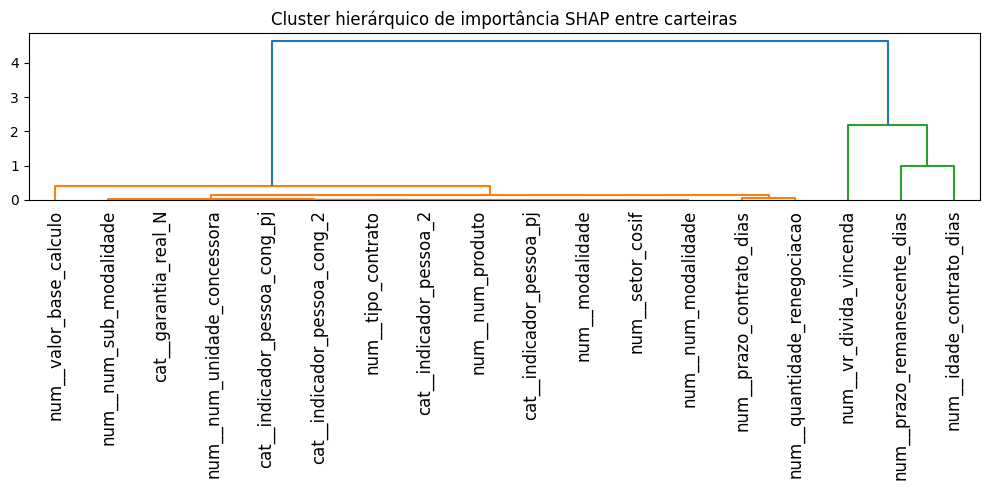


🕒 [6.5] Gráfico de estabilidade temporal (AUC por fold) — melhores modelos (H1)...


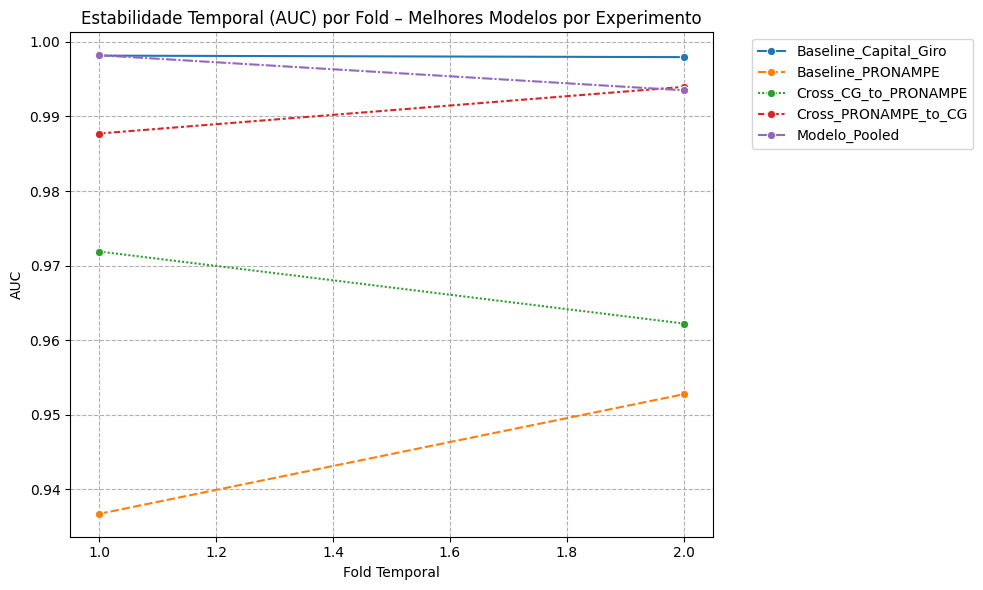


✅ ETAPA 6.0 CONCLUÍDA — Diagnóstico e robustez estatística executados com sucesso.
═══════════════════════════════════════════════════════════════════════════════════════════════



In [ ]:
# ============================================================
# [ETAPA 6.0] Diagnóstico e robustez estatística
#
# Objetivo:
#   • Aplicar testes estatísticos de robustez (Wilcoxon, KS, Mann–Whitney,
#     correção FDR) para comparar desempenhos entre experimentos.
#   • Alinhar e comparar importâncias SHAP entre carteiras (CG, PRONAMPE,
#     Pooled) via correlação de Spearman e clusterização.
#   • Gerar gráficos de estabilidade temporal por fold (AUC) para os
#     melhores modelos de cada experimento.
# ============================================================

print("\n" + "═"*95)
print("📈  ETAPA 6.0 — DIAGNÓSTICO E ROBUSTEZ ESTATÍSTICA")
print("═"*95)

from scipy.stats import anderson_ksamp  # necessário para o teste AD

# ------------------------------------------------------------
# 6.2) Testes estatísticos de robustez (H2/H3)
# ------------------------------------------------------------
print("\n🧪 [6.2] Rodando testes de significância estatística (KS, AD, Wilcoxon, Mann–Whitney, FDR)...")

def compara_series(x, y, label_a, label_b):
    """
    Retorna p-valores dos principais testes estatísticos de comparação
    entre duas séries (desempenho por fold):
      - Kolmogorov–Smirnov
      - Anderson–Darling k-sample
      - Wilcoxon (amostras pareadas)
      - Mann–Whitney U (amostras independentes)
    """
    ks_p = ks_2samp(x, y).pvalue

    try:
        ad_p = anderson_ksamp([x, y]).significance_level
    except Exception:
        ad_p = np.nan

    try:
        w_p = wilcoxon(x, y).pvalue
    except Exception:
        w_p = np.nan

    try:
        mw_p = mannwhitneyu(x, y).pvalue
    except Exception:
        mw_p = np.nan

    return {
        "A_vs_B": f"{label_a} vs {label_b}",
        "KS_p": ks_p,
        "AD_p": ad_p,
        "Wilcoxon_p": w_p,
        "MannWhitney_p": mw_p
    }

# Pares de experimentos a comparar (foco em H2/H3)
pares = [
    ("Baseline_Capital_Giro", "Baseline_PRONAMPE"),
    ("Baseline_Capital_Giro", "Cross_CG_to_PRONAMPE"),
    ("Baseline_PRONAMPE", "Cross_PRONAMPE_to_CG"),
    ("Baseline_Capital_Giro", "Modelo_Pooled"),
    ("Baseline_PRONAMPE", "Modelo_Pooled"),
]

# df_folds vem da CÉLULA 8 (df_fold_rows)
df_folds = pd.DataFrame(df_fold_rows)

pval_rows = []
for exp_a, exp_b in pares:
    f1_a = df_folds.query("Experimento == @exp_a")["F1"]
    f1_b = df_folds.query("Experimento == @exp_b")["F1"]

    print(f"   • Comparando F1 por fold: {exp_a} vs {exp_b} (n_a={len(f1_a)}, n_b={len(f1_b)})")
    res = compara_series(f1_a, f1_b, exp_a, exp_b)
    pval_rows.append(res)

df_pvals = pd.DataFrame(pval_rows)

# Correção de múltiplas comparações (FDR) para cada tipo de teste
p_cols = ["KS_p", "AD_p", "Wilcoxon_p", "MannWhitney_p"]
for col in p_cols:
    valid_pvals = df_pvals.loc[df_pvals[col].notnull(), col]
    if not valid_pvals.empty:
        reject, p_corr, _, _ = multipletests(valid_pvals, alpha=0.05, method="fdr_bh")
        df_pvals.loc[df_pvals[col].notnull(), col + "_FDR"] = p_corr
    else:
        df_pvals[col + "_FDR"] = np.nan

pvals_path = os.path.join(MODEL_SAVE_DIR, "pval_significancia_tests.csv")
df_pvals.to_csv(pvals_path, index=False)
print(f"   💾 Tabela de p-valores (com FDR) salva em:")
print(f"      -> {pvals_path}")

# ------------------------------------------------------------
# 6.4) Comparação SHAP e clusterização (H2)
# ------------------------------------------------------------
print("\n🧬 [6.4] Análise de correlação e clusterização SHAP entre carteiras (H2)...")

def load_shap_arrays(nome_exp):
    """
    Carrega os arrays SHAP e garante que os nomes das features são strings
    e que as importâncias são floats "limpos".
    """
    shap_vals = np.load(
        os.path.join(SHAP_SAVE_DIR, f"shap_values_{nome_exp}.npy"),
        allow_pickle=True
    )
    feat_names = np.load(
        os.path.join(SHAP_SAVE_DIR, f"feature_names_{nome_exp}.npy"),
        allow_pickle=True
    )

    # Importância média absoluta
    imp_raw = np.abs(shap_vals).mean(axis=0).flatten()

    # Força conversão para listas "limpas"
    feat_list = [str(x) for x in feat_names.flatten().tolist()]
    imp_list = [x[0] if isinstance(x, np.ndarray) else x for x in imp_raw]
    imp_list = np.array(imp_list).astype(float).tolist()

    return imp_list, feat_list

# Carregando SHAP das três configurações: CG, PRONAMPE e Pooled
print("   • Carregando arrays SHAP (Baseline_Capital_Giro, Baseline_PRONAMPE, Modelo_Pooled)...")
imp_cg, feat_cg = load_shap_arrays("Baseline_Capital_Giro")
imp_pr, feat_pr = load_shap_arrays("Baseline_PRONAMPE")
imp_pool, feat_pool = load_shap_arrays("Modelo_Pooled")

min_len = min(len(imp_cg), len(imp_pr), len(imp_pool))
print(f"   • Tamanho mínimo comum entre configurações: {min_len} features (para alinhamento)")

# Criação dos DataFrames temporários de importância
df_imp_temp = pd.DataFrame({
    "Feature": feat_pool[:min_len],
    "SHAP_POOL": imp_pool[:min_len]
})
df_cg_temp = pd.DataFrame({
    "Feature": feat_cg[:min_len],
    "SHAP_CG": imp_cg[:min_len]
})
df_pr_temp = pd.DataFrame({
    "Feature": feat_pr[:min_len],
    "SHAP_PR": imp_pr[:min_len]
})

# Merge alinhado por feature (usando feat_pool como mestre)
df_imp = (
    df_imp_temp
    .merge(df_cg_temp, on="Feature", how="left")
    .merge(df_pr_temp, on="Feature", how="left")
    .fillna(0)
    .drop(columns=["SHAP_POOL"])
)

shap_imp_path = os.path.join(MODEL_SAVE_DIR, "shap_importancias_alinhavel.csv")
df_imp.to_csv(shap_imp_path, index=False)
print(f"   💾 Tabela SHAP de importâncias alinhadas salva em:")
print(f"      -> {shap_imp_path}")

# Correlação de Spearman entre importâncias CG vs PRONAMPE
rho, p_spear = spearmanr(
    df_imp["SHAP_CG"].to_numpy().ravel().astype(float),
    df_imp["SHAP_PR"].to_numpy().ravel().astype(float)
)

spearman_path = os.path.join(MODEL_SAVE_DIR, "shap_correlation_summary.csv")
pd.DataFrame([{"Spearman_rho": rho, "p_value": p_spear}]).to_csv(spearman_path, index=False)
print(f"   🔗 Correlação de Spearman (CG vs PR) salva em:")
print(f"      -> {spearman_path}")
print(f"   • rho={rho:.3f}, p={p_spear:.5f}")

# Plot do dendrograma de cluster hierárquico
from scipy.cluster.hierarchy import linkage, dendrogram

print("   📉 Gerando dendrograma de cluster hierárquico (SHAP_CG vs SHAP_PR)...")
dados_cluster = df_imp[["SHAP_CG", "SHAP_PR"]].dropna()
linkage_mat = linkage(dados_cluster, method="ward")
labels_validos = df_imp.loc[dados_cluster.index, "Feature"].tolist()

plt.figure(figsize=(10, 5))
dendrogram(linkage_mat, labels=labels_validos, leaf_rotation=90)
plt.title("Cluster hierárquico de importância SHAP entre carteiras")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6.5) Diagnóstico de estabilidade temporal (Figuras Finais – H1)
# ------------------------------------------------------------
print("\n🕒 [6.5] Gráfico de estabilidade temporal (AUC por fold) — melhores modelos (H1)...")

# Seleciona somente os folds dos modelos vencedores por experimento
df_plot_est = df_folds.copy()
df_plot_est["Modelo_Vencedor"] = df_plot_est.apply(
    lambda row: ALL_BEST_MODELS.get(row["Experimento"])
    if row["Modelo"] == ALL_BEST_MODELS.get(row["Experimento"])
    else None,
    axis=1
)
df_plot_est = df_plot_est.dropna(subset=["Modelo_Vencedor"])

import seaborn as sns
plt.figure(figsize=(10, 6))
sns.lineplot(
    x="Fold",
    y="AUC",
    hue="Experimento",
    style="Experimento",
    data=df_plot_est,
    marker="o",
    ci=None
)
plt.title("Estabilidade Temporal (AUC) por Fold – Melhores Modelos por Experimento")
plt.xlabel("Fold Temporal")
plt.ylabel("AUC")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

print("\n✅ ETAPA 6.0 CONCLUÍDA — Diagnóstico e robustez estatística executados com sucesso.")
print("═"*95 + "\n")




═══════════════════════════════════════════════════════════════════════════════════════════════
📊  ETAPA 7.0 — VISUALIZAÇÕES PRINCIPAIS DOS RESULTADOS
═══════════════════════════════════════════════════════════════════════════════════════════════
📁 Pasta de gráficos criada/em uso: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos

📌 [7.1] Montando DataFrame com desempenho dos melhores modelos por experimento...
   • Experimentos considerados........: 5
   • Linhas (1 por experimento).......: 5

   🧾 Resumo dos melhores modelos por experimento:


,Experimento,Modelo_Nome,F1,AUC,Recall,Precisao,Acurácia,Gini,Lift@10%
0,Baseline_Capital_Giro,GB,0.981834,0.997959,0.992131,0.971749,0.974866,0.995918,1.460709
1,Baseline_PRONAMPE,LR,0.546208,0.951350,0.998316,0.375951,0.889234,0.902700,6.463902
2,Cross_CG_to_PRONAMPE,GB,0.517133,0.971722,0.682064,0.416435,0.955330,0.943444,9.974337
3,Cross_PRONAMPE_to_CG,LR,0.800639,0.980545,1.000000,0.667555,0.687595,0.961090,1.580307
4,Modelo_Pooled,RF,0.927687,0.994602,0.902307,0.954536,0.961999,0.989204,3.700971



📊 [7.2] Gerando gráficos de barras (F1, AUC, Gini, Lift@10%)...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos/comparacao_f1_experimentos.png


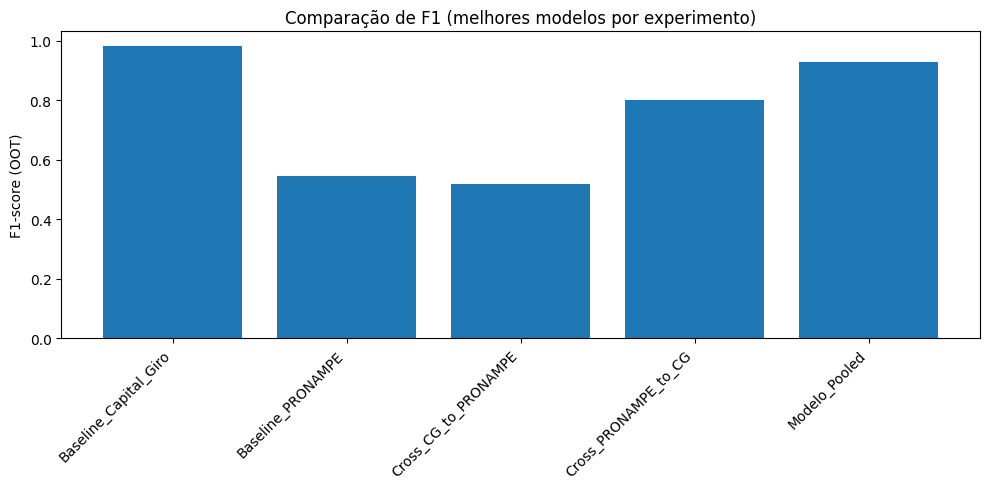

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos/comparacao_auc_experimentos.png


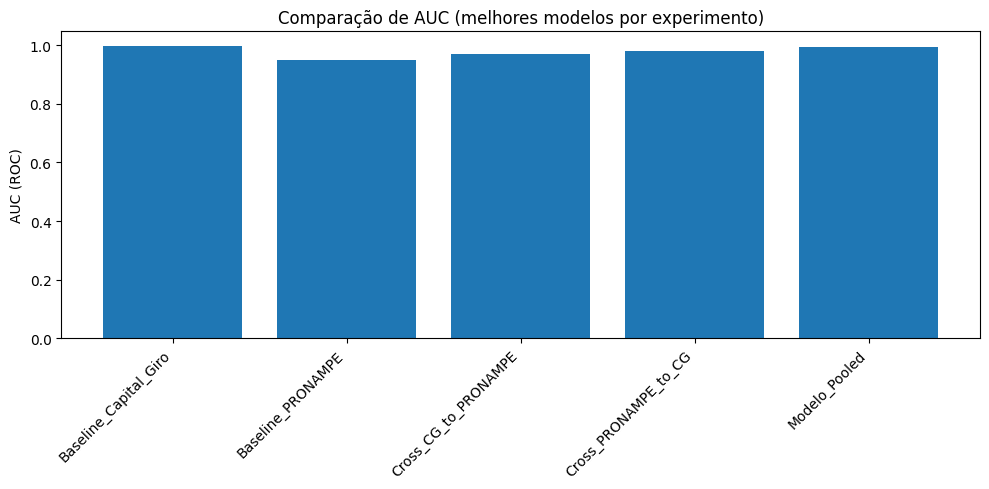

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos/comparacao_gini_experimentos.png


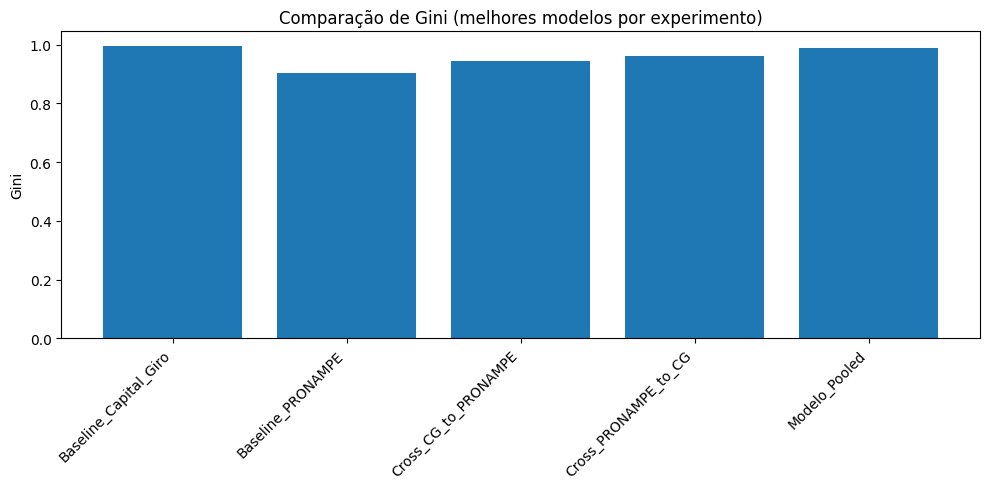

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos/comparacao_lift10_experimentos.png


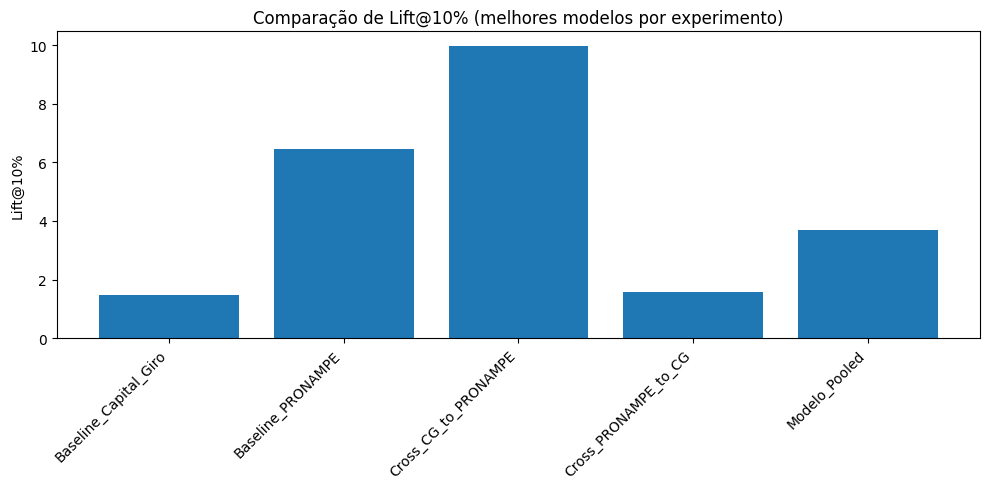


📈 [7.3] Gerando curvas de captura de default (Cumulative Gains)...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos/curva_captura_default_baseline_vs_pooled.png


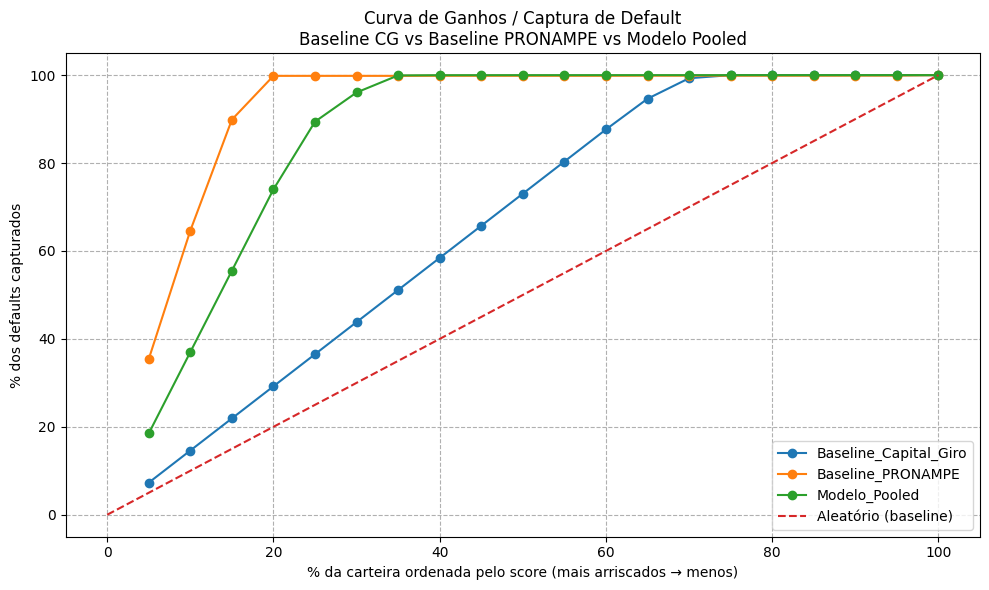


🧬 [7.4] Gerando gráfico de importância SHAP (Top 20) – Modelo Pooled...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos/shap_top20_pooled.png


<Figure size 800x600 with 0 Axes>

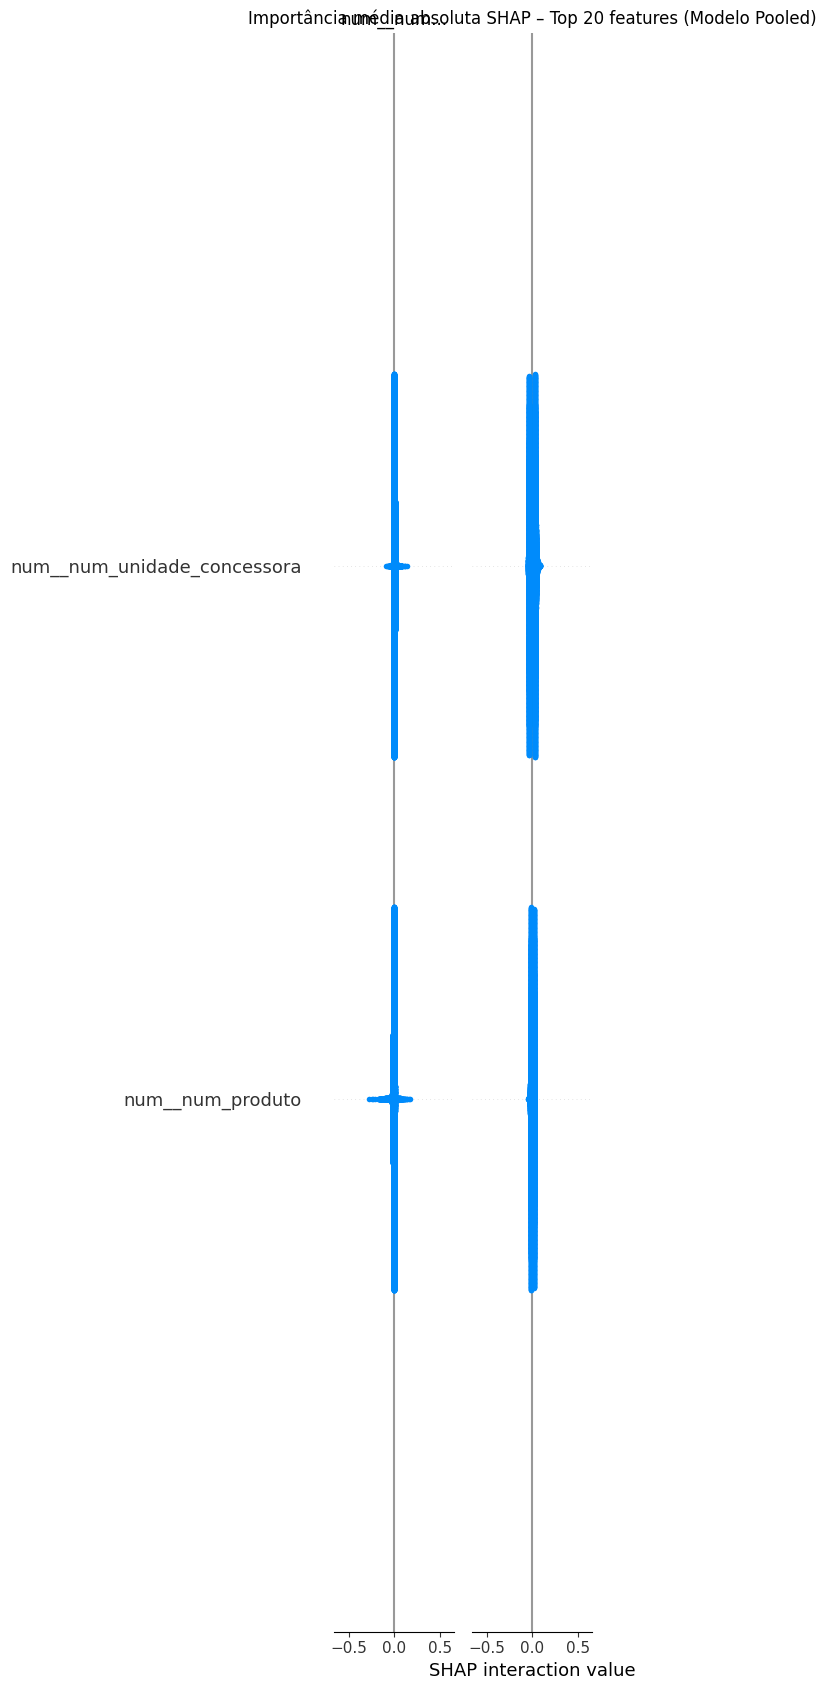


✅ ETAPA 7.0 CONCLUÍDA — Gráficos principais gerados e salvos.



In [ ]:
# ============================================================
# [ETAPA 7.0] Visualizações principais dos resultados
#
# Objetivo:
#   • Produzir gráficos sintéticos para resumir os resultados dos
#     experimentos:
#       (a) Comparação de desempenho dos melhores modelos (F1, AUC, Gini, Lift);
#       (b) Curvas de ganhos/captura de default (Baseline vs Pooled);
#       (c) Resumo de importância SHAP (Modelo Pooled).
# ============================================================

print("\n" + "═"*95)
print("📊  ETAPA 7.0 — VISUALIZAÇÕES PRINCIPAIS DOS RESULTADOS")
print("═"*95)

from sklearn.metrics import precision_recall_curve, average_precision_score

# Criar pasta para salvar os gráficos
GRAFICOS_DIR = os.path.join(MODEL_SAVE_DIR, "graficos")
os.makedirs(GRAFICOS_DIR, exist_ok=True)
print(f"📁 Pasta de gráficos criada/em uso: {GRAFICOS_DIR}")

# Função auxiliar para salvar e exibir figuras
def salvar_fig(nome_arquivo):
    caminho = os.path.join(GRAFICOS_DIR, nome_arquivo)
    plt.savefig(caminho, dpi=300, bbox_inches="tight")
    print(f"   💾 Gráfico salvo em: {caminho}")
    plt.show()

# ------------------------------------------------------------
# 7.1) Tabela base com melhores modelos por experimento
# ------------------------------------------------------------
print("\n📌 [7.1] Montando DataFrame com desempenho dos melhores modelos por experimento...")

# Garante que df_final_results e df_eff existem (ETAPA 5.0)
# df_final_results: resultados OOT
# df_eff: Gini e Lift@10%

df_best_rows = []

for exp_name, best_model_name in ALL_BEST_MODELS.items():
    row = df_final_results.query(
        "Experimento == @exp_name and Modelo_Nome == @best_model_name"
    ).copy()

    if row.empty:
        continue

    row = row.iloc[0].to_dict()
    # Anexa Gini e Lift a partir de df_eff
    eff_row = df_eff.query(
        "Experimento == @exp_name and Modelo == @best_model_name"
    )
    if not eff_row.empty:
        row["Gini"] = float(eff_row.iloc[0]["Gini"])
        row["Lift@10%"] = float(eff_row.iloc[0]["Lift@10%"])
    else:
        row["Gini"] = None
        row["Lift@10%"] = None

    df_best_rows.append(row)

df_best = pd.DataFrame(df_best_rows)

print("   • Experimentos considerados........:", df_best["Experimento"].nunique())
print("   • Linhas (1 por experimento).......:", len(df_best))

display_cols = [
    "Experimento", "Modelo_Nome", "F1", "AUC",
    "Recall", "Precisao", "Acurácia", "Gini", "Lift@10%"
]
print("\n   🧾 Resumo dos melhores modelos por experimento:")
display(df_best[display_cols])

# ------------------------------------------------------------
# 7.2) Gráficos de barras – F1, AUC, Gini, Lift@10%
# ------------------------------------------------------------
print("\n📊 [7.2] Gerando gráficos de barras (F1, AUC, Gini, Lift@10%)...")

plt.figure(figsize=(10, 5))
plt.bar(df_best["Experimento"], df_best["F1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score (OOT)")
plt.title("Comparação de F1 (melhores modelos por experimento)")
plt.tight_layout()
salvar_fig("comparacao_f1_experimentos.png")

plt.figure(figsize=(10, 5))
plt.bar(df_best["Experimento"], df_best["AUC"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("AUC (ROC)")
plt.title("Comparação de AUC (melhores modelos por experimento)")
plt.tight_layout()
salvar_fig("comparacao_auc_experimentos.png")

plt.figure(figsize=(10, 5))
plt.bar(df_best["Experimento"], df_best["Gini"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Gini")
plt.title("Comparação de Gini (melhores modelos por experimento)")
plt.tight_layout()
salvar_fig("comparacao_gini_experimentos.png")

plt.figure(figsize=(10, 5))
plt.bar(df_best["Experimento"], df_best["Lift@10%"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Lift@10%")
plt.title("Comparação de Lift@10% (melhores modelos por experimento)")
plt.tight_layout()
salvar_fig("comparacao_lift10_experimentos.png")

# ------------------------------------------------------------
# 7.3) Curvas de ganhos/captura – Baseline CG, Baseline PRONAMPE, Pooled
# ------------------------------------------------------------
print("\n📈 [7.3] Gerando curvas de captura de default (Cumulative Gains)...")

def curva_captura(y_true, y_score, n_pontos=20):
    """Retorna eixo x (% da carteira) e y (% dos defaults capturados)."""
    df_tmp = pd.DataFrame({"y": y_true, "score": y_score}).sort_values(
        "score", ascending=False
    )
    total_defaults = df_tmp["y"].sum()
    n = len(df_tmp)
    xs, ys = [], []

    for frac in np.linspace(0.05, 1.0, n_pontos):
        k = int(np.ceil(frac * n))
        sub = df_tmp.iloc[:k]
        captured = sub["y"].sum()
        xs.append(frac)
        ys.append(captured / total_defaults if total_defaults > 0 else 0.0)

    return np.array(xs), np.array(ys)

# Experimentos foco: baseline + pooled
exp_focus = [
    "Baseline_Capital_Giro",
    "Baseline_PRONAMPE",
    "Modelo_Pooled"
]

plt.figure(figsize=(10, 6))

for exp_name in exp_focus:
    best_model = ALL_BEST_MODELS.get(exp_name)
    if best_model is None:
        continue
    detalhe = ALL_DETALHES_MODELOS[exp_name][best_model]
    y_true = detalhe["y_true_test"]
    y_score = detalhe["y_score_test"]

    xs, ys = curva_captura(y_true, y_score)
    plt.plot(xs * 100, ys * 100, marker="o", label=exp_name)

plt.plot([0, 100], [0, 100], linestyle="--", label="Aleatório (baseline)")
plt.xlabel("% da carteira ordenada pelo score (mais arriscados → menos)")
plt.ylabel("% dos defaults capturados")
plt.title("Curva de Ganhos / Captura de Default\nBaseline CG vs Baseline PRONAMPE vs Modelo Pooled")
plt.legend()
plt.grid(True, linestyle="--")
plt.tight_layout()
salvar_fig("curva_captura_default_baseline_vs_pooled.png")

# ------------------------------------------------------------
# 7.4) Resumo SHAP em barras – Modelo Pooled (Top 20 features)
# ------------------------------------------------------------
print("\n🧬 [7.4] Gerando gráfico de importância SHAP (Top 20) – Modelo Pooled...")

try:
    shap_vals_pool = np.load(
        os.path.join(SHAP_SAVE_DIR, "shap_values_Modelo_Pooled.npy"),
        allow_pickle=True
    )
    feat_names_pool = np.load(
        os.path.join(SHAP_SAVE_DIR, "feature_names_Modelo_Pooled.npy"),
        allow_pickle=True
    )

    # Se shap_vals_pool for lista (ex: [classe0, classe1]), pega classe 1
    if isinstance(shap_vals_pool, list) or (
        hasattr(shap_vals_pool, "dtype") and shap_vals_pool.dtype == "object"
    ):
        # tentativa robusta
        try:
            shap_vals_pool = shap_vals_pool[1]
        except Exception:
            shap_vals_pool = shap_vals_pool[0]

    # Gráfico de barras (importância média absoluta)
    plt.figure(figsize=(8, 6))
    shap.summary_plot(
        shap_vals_pool,
        feature_names=feat_names_pool,
        plot_type="bar",
        max_display=20,
        show=False
    )
    plt.title("Importância média absoluta SHAP – Top 20 features (Modelo Pooled)")
    plt.tight_layout()
    salvar_fig("shap_top20_pooled.png")

except Exception as e:
    print("   ⚠ Não foi possível gerar o gráfico SHAP do Modelo Pooled.")
    print("   Detalhes do erro:", e)

print("\n✅ ETAPA 7.0 CONCLUÍDA — Gráficos principais gerados e salvos.\n")



═══════════════════════════════════════════════════════════════════════════════════════════════
📊  ETAPA 7.1 — VISUALIZAÇÕES AVANÇADAS DOS RESULTADOS
═══════════════════════════════════════════════════════════════════════════════════════════════
📁 Pasta de gráficos avançados criada/em uso: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados

📌 [7.1.1] Boxplots de F1 e AUC por experimento (melhores modelos, por fold)...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/boxplot_f1_melhores_modelos_por_experimento.png


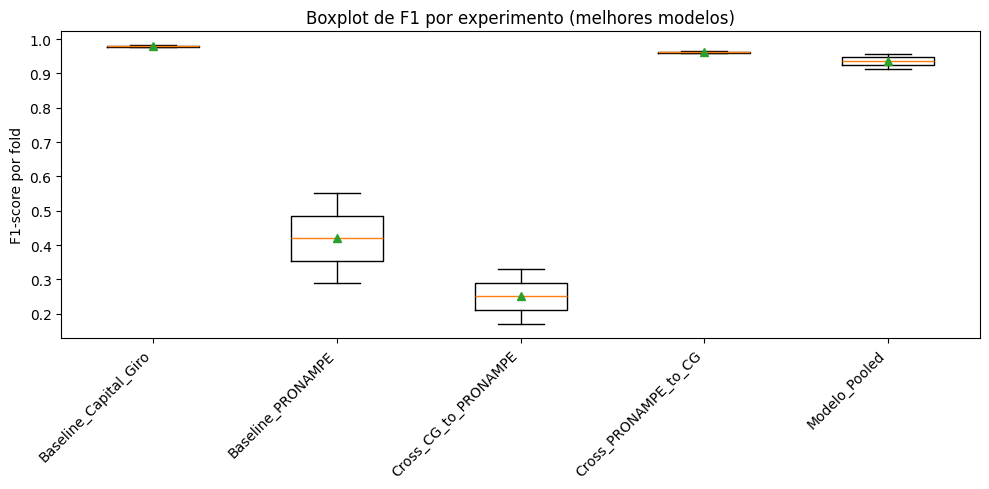

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/boxplot_auc_melhores_modelos_por_experimento.png


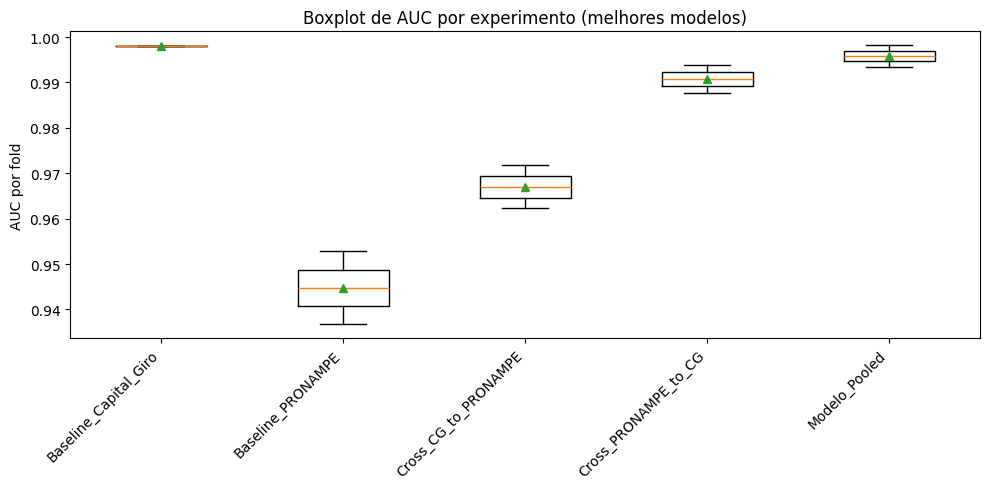


📈 [7.1.2] Curvas ROC e Precision–Recall dos melhores modelos (experimentos-chave)...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/curva_roc_Baseline_Capital_Giro.png


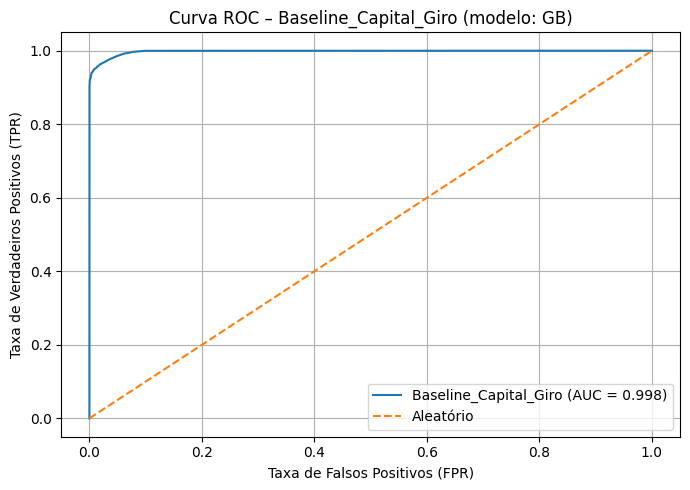

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/curva_pr_Baseline_Capital_Giro.png


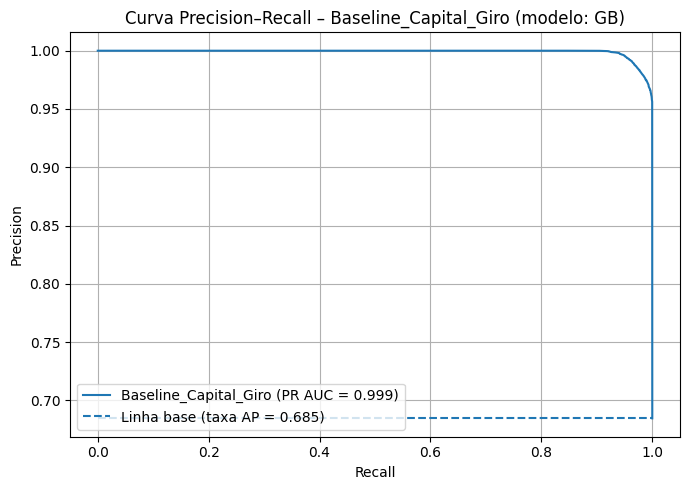

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/curva_roc_Baseline_PRONAMPE.png


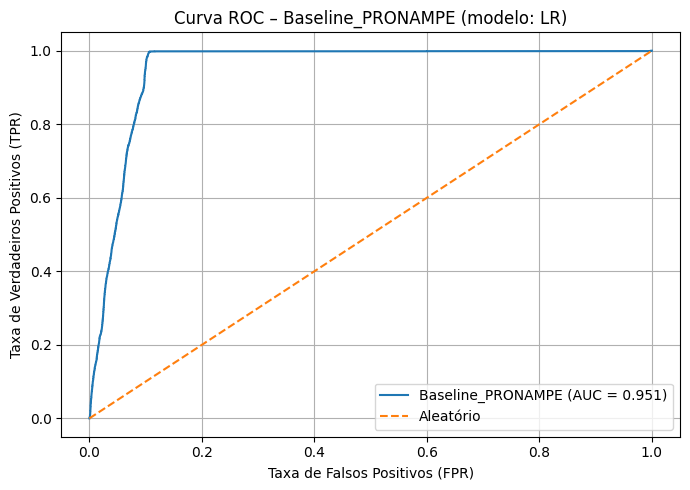

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/curva_pr_Baseline_PRONAMPE.png


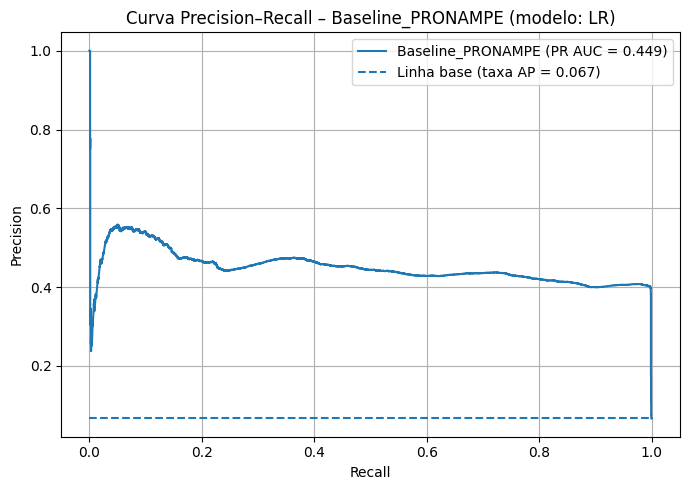

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/curva_roc_Modelo_Pooled.png


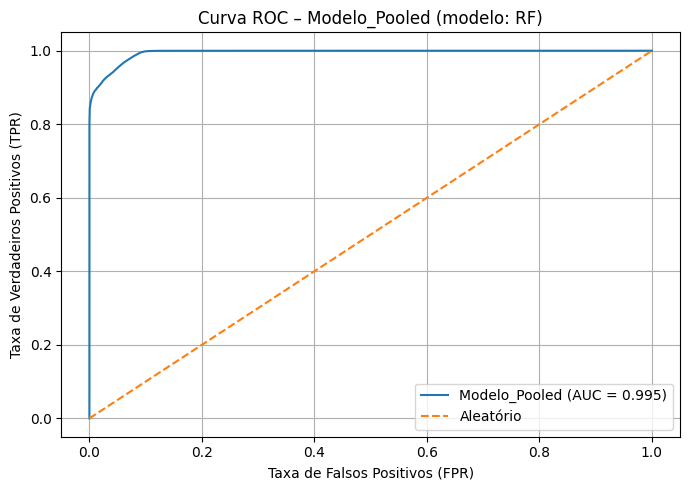

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/curva_pr_Modelo_Pooled.png


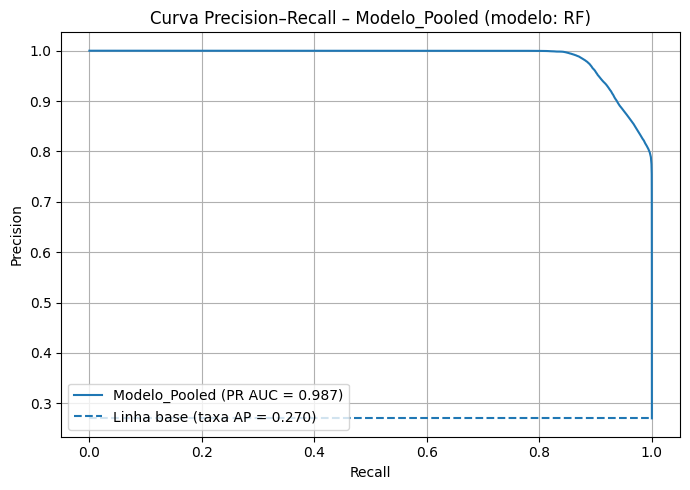


🧮 [7.1.3] Heatmap de correlação entre métricas (F1, AUC, Gini, Lift@10%)...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/heatmap_correlacao_metricas.png


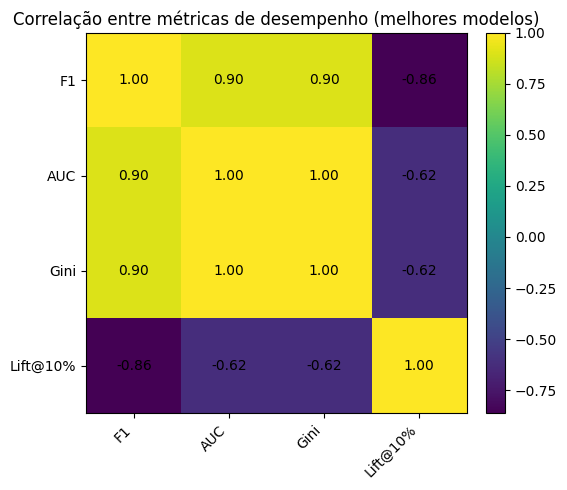


🧬 [7.1.4] Gerando gráficos SHAP Beeswarm (CG, PRONAMPE e Pooled)...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/shap_beeswarm_baseline_cg.png


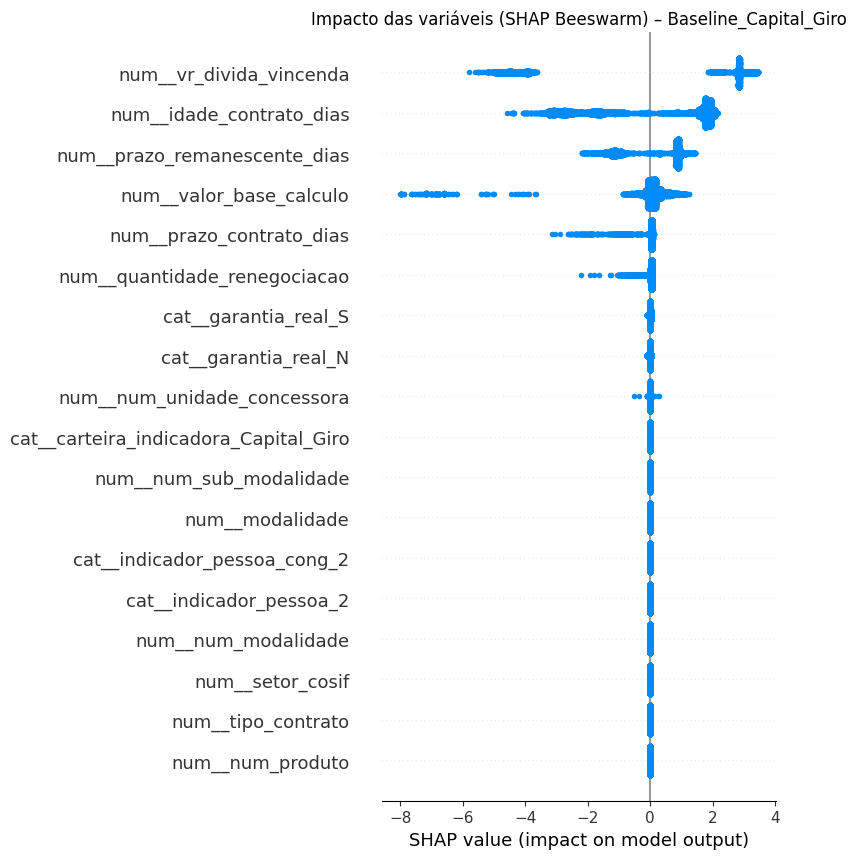

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/shap_beeswarm_baseline_pronampe.png


<Figure size 800x600 with 0 Axes>

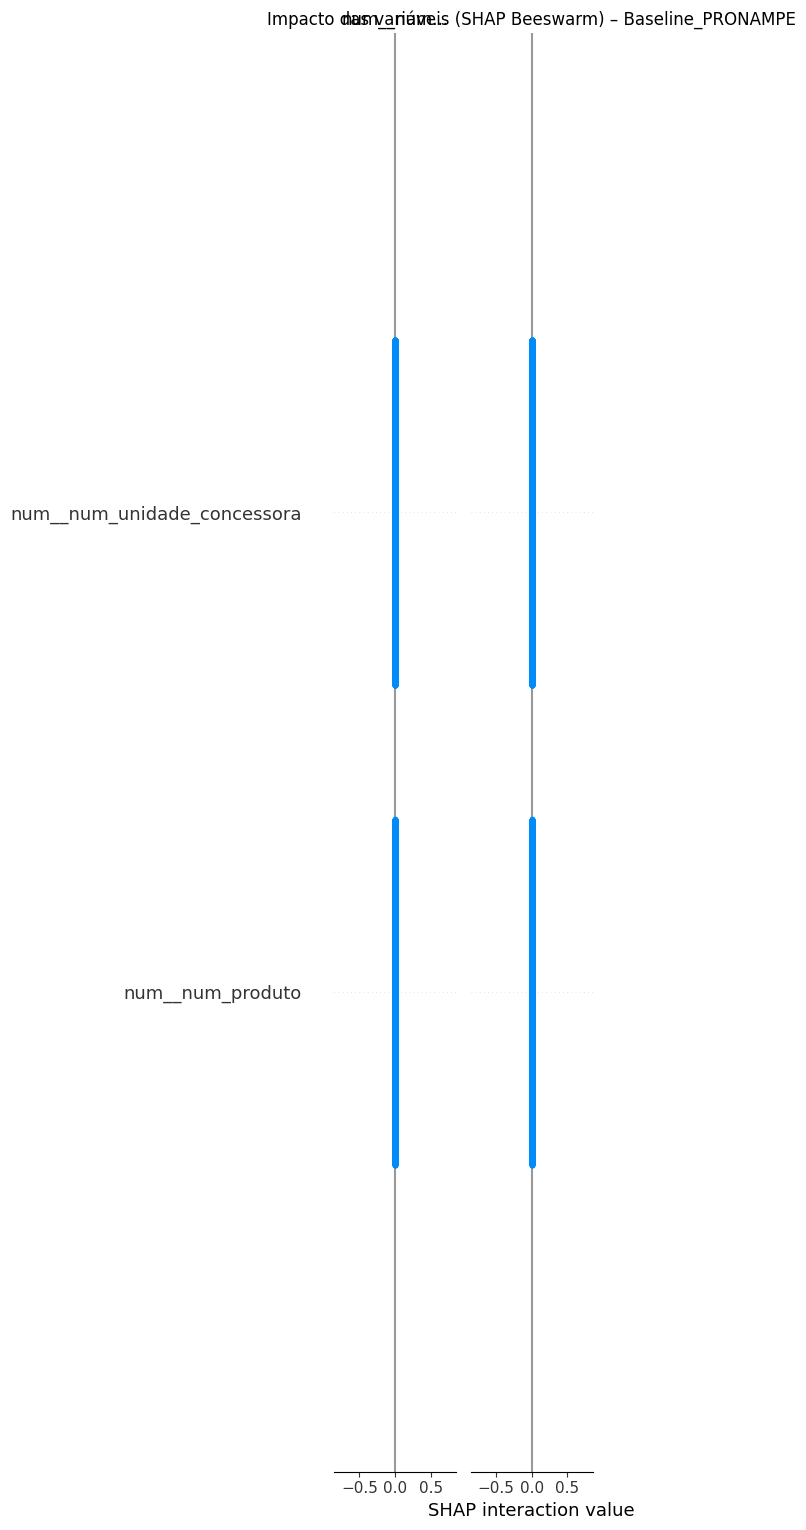

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/shap_beeswarm_modelo_pooled.png


<Figure size 800x600 with 0 Axes>

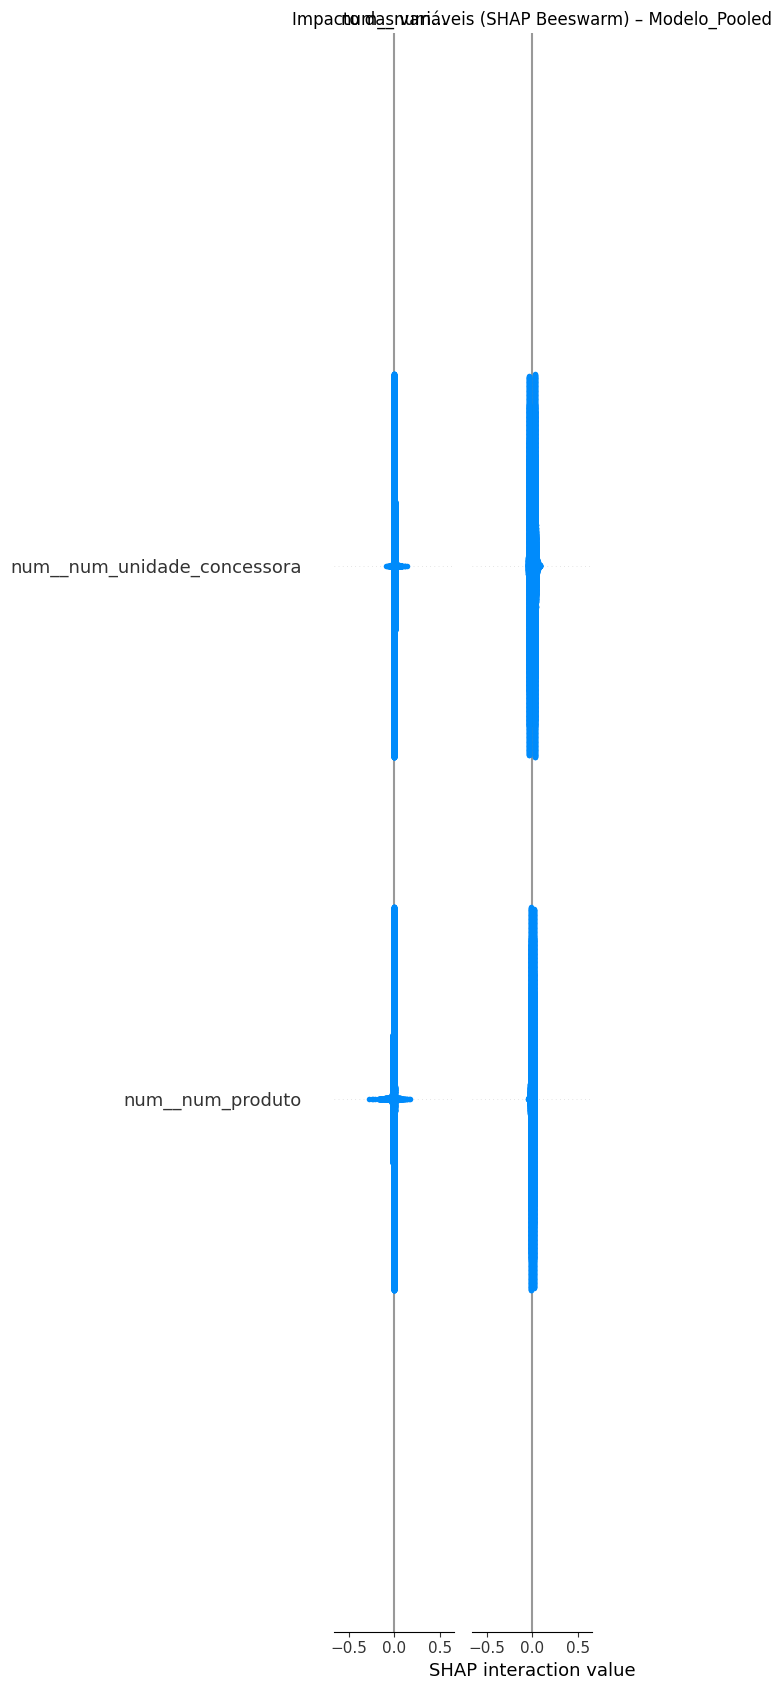


✅ ETAPA 7.1 CONCLUÍDA — Visualizações avançadas geradas e salvas.



In [ ]:
# ============================================================
# [ETAPA 7.1] Visualizações avançadas dos resultados
#
# Objetivo:
#   • Gerar gráficos adicionais que aprofundam a análise empírica:
#       (a) Boxplots de F1 e AUC por experimento (robustez temporal – H1);
#       (b) Curvas ROC e Precision–Recall dos melhores modelos;
#       (c) Heatmap de correlação entre métricas (F1, AUC, Gini, Lift);
#       (d) SHAP Beeswarm para CG, PRONAMPE e Modelo Pooled (H2/H3).
# ============================================================

print("\n" + "═"*95)
print("📊  ETAPA 7.1 — VISUALIZAÇÕES AVANÇADAS DOS RESULTADOS")
print("═"*95)

from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

# ------------------------------------------------------------
# Pasta para salvar gráficos avançados
# ------------------------------------------------------------
GRAFICOS_AVANC_DIR = os.path.join(MODEL_SAVE_DIR, "graficos_avancados")
os.makedirs(GRAFICOS_AVANC_DIR, exist_ok=True)
print(f"📁 Pasta de gráficos avançados criada/em uso: {GRAFICOS_AVANC_DIR}")

def salvar_fig_avancado(nome_arquivo):
    """Salva figura atual na pasta de gráficos avançados e exibe."""
    caminho = os.path.join(GRAFICOS_AVANC_DIR, nome_arquivo)
    plt.savefig(caminho, dpi=300, bbox_inches="tight")
    print(f"   💾 Gráfico salvo em: {caminho}")
    plt.show()

# ------------------------------------------------------------
# 7.1.1) Boxplots de F1 e AUC por experimento (melhores modelos) – H1
# ------------------------------------------------------------
print("\n📌 [7.1.1] Boxplots de F1 e AUC por experimento (melhores modelos, por fold)...")

# Usa df_folds (ETAPA 5.0) filtrando apenas o modelo vencedor de cada experimento
df_box = df_folds.copy()
df_box["Modelo_Vencedor"] = df_box["Experimento"].map(ALL_BEST_MODELS)
df_box = df_box[df_box["Modelo"] == df_box["Modelo_Vencedor"]].copy()

if df_box.empty:
    print("   ⚠ Nenhum dado disponível para boxplots (df_box vazio).")
else:
    # Boxplot de F1
    plt.figure(figsize=(10, 5))
    # prepara dados em ordem de Experimento
    exp_order = df_box["Experimento"].unique().tolist()
    data_f1 = [df_box[df_box["Experimento"] == exp]["F1"].values for exp in exp_order]
    plt.boxplot(data_f1, labels=exp_order, showmeans=True)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("F1-score por fold")
    plt.title("Boxplot de F1 por experimento (melhores modelos)")
    plt.tight_layout()
    salvar_fig_avancado("boxplot_f1_melhores_modelos_por_experimento.png")

    # Boxplot de AUC
    plt.figure(figsize=(10, 5))
    data_auc = [df_box[df_box["Experimento"] == exp]["AUC"].values for exp in exp_order]
    plt.boxplot(data_auc, labels=exp_order, showmeans=True)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("AUC por fold")
    plt.title("Boxplot de AUC por experimento (melhores modelos)")
    plt.tight_layout()
    salvar_fig_avancado("boxplot_auc_melhores_modelos_por_experimento.png")

# ------------------------------------------------------------
# 7.1.2) Curvas ROC e Precision–Recall dos melhores modelos – H1/H3
# ------------------------------------------------------------
print("\n📈 [7.1.2] Curvas ROC e Precision–Recall dos melhores modelos (experimentos-chave)...")

exp_focus_curvas = [
    "Baseline_Capital_Giro",
    "Baseline_PRONAMPE",
    "Modelo_Pooled"
]

for exp_name in exp_focus_curvas:
    best_model = ALL_BEST_MODELS.get(exp_name)
    if best_model is None:
        print(f"   ⚠ Nenhum modelo vencedor encontrado para {exp_name}.")
        continue

    detalhe = ALL_DETALHES_MODELOS[exp_name][best_model]
    y_true = detalhe["y_true_test"]
    y_score = detalhe["y_score_test"]

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"{exp_name} (AUC = {auc_val:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
    plt.xlabel("Taxa de Falsos Positivos (FPR)")
    plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
    plt.title(f"Curva ROC – {exp_name} (modelo: {best_model})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    salvar_fig_avancado(f"curva_roc_{exp_name}.png")

    # Precision–Recall
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label=f"{exp_name} (PR AUC = {pr_auc:.3f})")
    base_rate = y_true.mean()
    plt.hlines(base_rate, 0, 1, linestyles="dashed", label=f"Linha base (taxa AP = {base_rate:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Curva Precision–Recall – {exp_name} (modelo: {best_model})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    salvar_fig_avancado(f"curva_pr_{exp_name}.png")

# ------------------------------------------------------------
# 7.1.3) Heatmap de correlação entre métricas (F1, AUC, Gini, Lift@10%)
# ------------------------------------------------------------
print("\n🧮 [7.1.3] Heatmap de correlação entre métricas (F1, AUC, Gini, Lift@10%)...")

metric_cols = ["F1", "AUC", "Gini", "Lift@10%"]
df_corr_base = df_best[metric_cols].copy().dropna(axis=1, how="all")

if df_corr_base.empty:
    print("   ⚠ Não há métricas suficientes para calcular a correlação.")
else:
    corr_mat = df_corr_base.corr()

    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr_mat, interpolation="nearest")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(metric_cols)), metric_cols, rotation=45, ha="right")
    plt.yticks(range(len(metric_cols)), metric_cols)
    plt.title("Correlação entre métricas de desempenho (melhores modelos)")
    # Anota os valores na matriz
    for i in range(len(metric_cols)):
        for j in range(len(metric_cols)):
            val = corr_mat.iloc[i, j]
            plt.text(j, i, f"{val:.2f}", ha="center", va="center")
    plt.tight_layout()
    salvar_fig_avancado("heatmap_correlacao_metricas.png")

# ------------------------------------------------------------
# 7.1.4) SHAP Beeswarm – CG, PRONAMPE e Pooled – H2/H3
# ------------------------------------------------------------
print("\n🧬 [7.1.4] Gerando gráficos SHAP Beeswarm (CG, PRONAMPE e Pooled)...")

def plota_shap_beeswarm(nome_exp, nome_arquivo_png):
    """Carrega arrays SHAP e gera beeswarm plot para o experimento."""
    try:
        shap_vals = np.load(
            os.path.join(SHAP_SAVE_DIR, f"shap_values_{nome_exp}.npy"),
            allow_pickle=True
        )
        feat_names = np.load(
            os.path.join(SHAP_SAVE_DIR, f"feature_names_{nome_exp}.npy"),
            allow_pickle=True
        )

        # Trata caso de lista [classe0, classe1]
        if isinstance(shap_vals, list) or (
            hasattr(shap_vals, "dtype") and shap_vals.dtype == "object"
        ):
            try:
                shap_vals = shap_vals[1]
            except Exception:
                shap_vals = shap_vals[0]

        plt.figure(figsize=(8, 6))
        shap.summary_plot(
            shap_vals,
            feature_names=feat_names,
            max_display=20,
            show=False
        )
        plt.title(f"Impacto das variáveis (SHAP Beeswarm) – {nome_exp}")
        plt.tight_layout()
        salvar_fig_avancado(nome_arquivo_png)

    except Exception as e:
        print(f"   ⚠ Não foi possível gerar SHAP Beeswarm para {nome_exp}.")
        print("     Erro:", e)

# Baseline CG
plota_shap_beeswarm("Baseline_Capital_Giro", "shap_beeswarm_baseline_cg.png")

# Baseline PRONAMPE
plota_shap_beeswarm("Baseline_PRONAMPE", "shap_beeswarm_baseline_pronampe.png")

# Modelo Pooled
plota_shap_beeswarm("Modelo_Pooled", "shap_beeswarm_modelo_pooled.png")

print("\n✅ ETAPA 7.1 CONCLUÍDA — Visualizações avançadas geradas e salvas.\n")



═══════════════════════════════════════════════════════════════════════════════════════════════
📊  ETAPA 7.2 — VISUALIZAÇÕES COMPLEMENTARES DOS RESULTADOS
═══════════════════════════════════════════════════════════════════════════════════════════════
📁 Pasta de gráficos avançados em uso: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados

🧾 [7.2.1] Gerando matrizes de confusão (melhores modelos)...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/matriz_confusao_Baseline_Capital_Giro.png


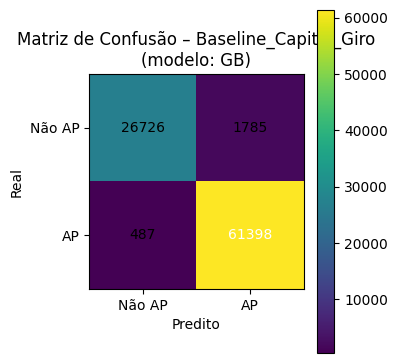

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/matriz_confusao_Baseline_PRONAMPE.png


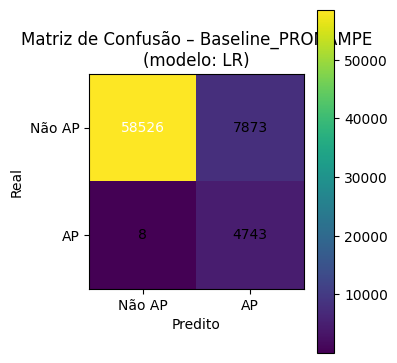

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/matriz_confusao_Cross_CG_to_PRONAMPE.png


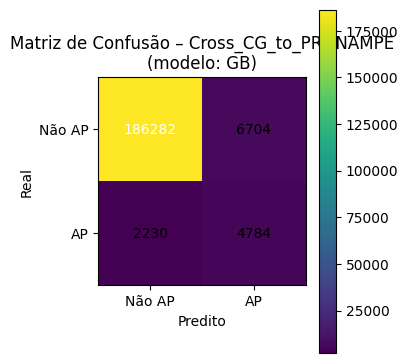

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/matriz_confusao_Cross_PRONAMPE_to_CG.png


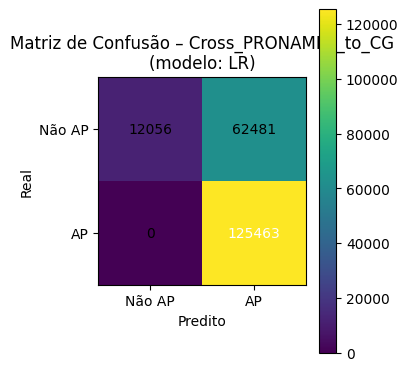

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/matriz_confusao_Modelo_Pooled.png


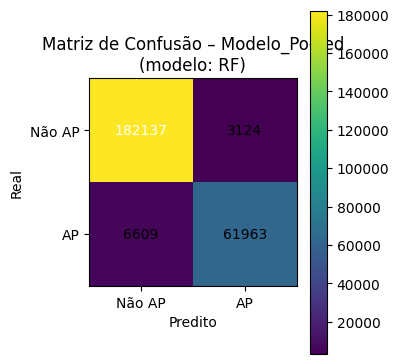


📈 [7.2.2] Distribuição de scores por classe (0 = bom, 1 = AP)...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/distribuicao_scores_por_classe_Baseline_Capital_Giro.png


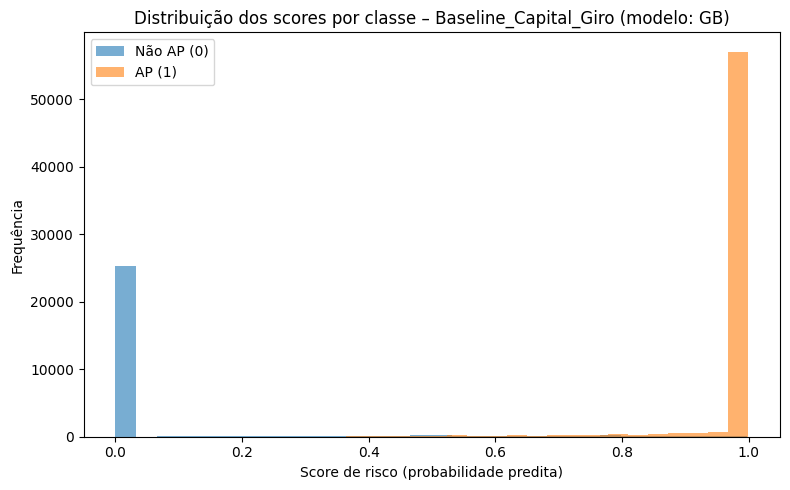

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/distribuicao_scores_por_classe_Baseline_PRONAMPE.png


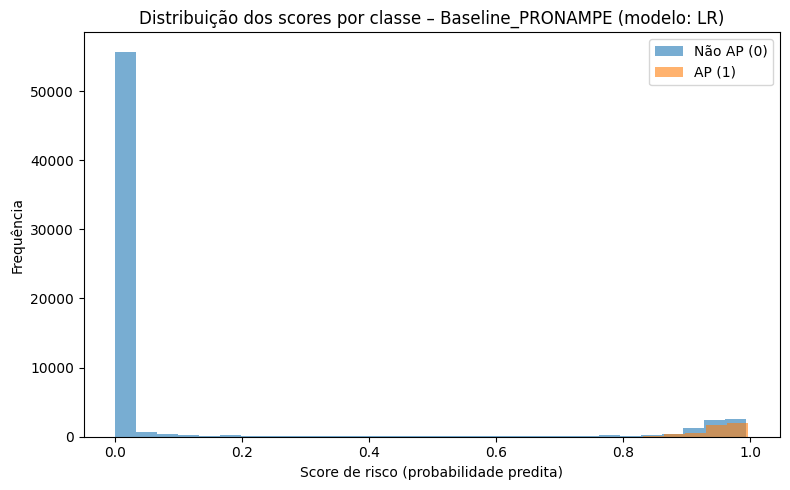

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/distribuicao_scores_por_classe_Modelo_Pooled.png


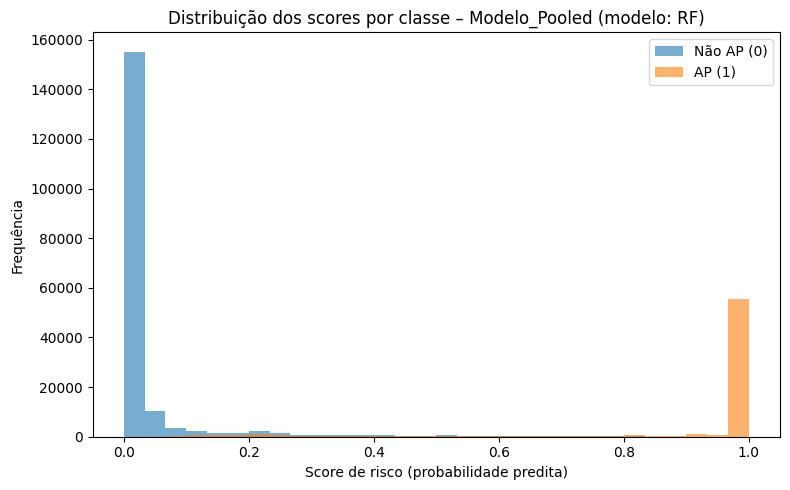


📊 [7.2.3] Gerando gráficos KS-Plot (CDF dos scores por classe)...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/ks_plot_Baseline_Capital_Giro.png


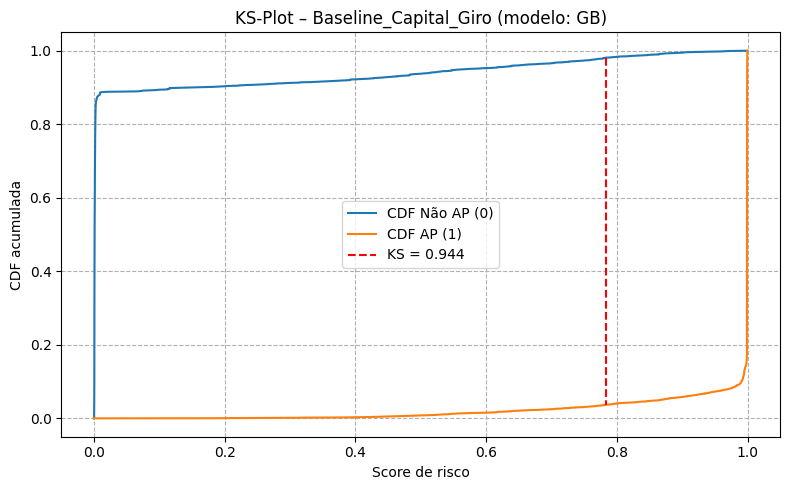

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/ks_plot_Baseline_PRONAMPE.png


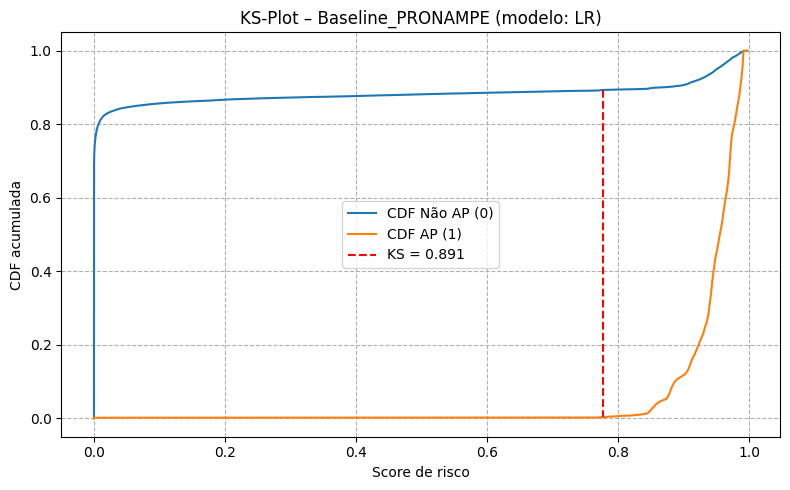

   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/ks_plot_Modelo_Pooled.png


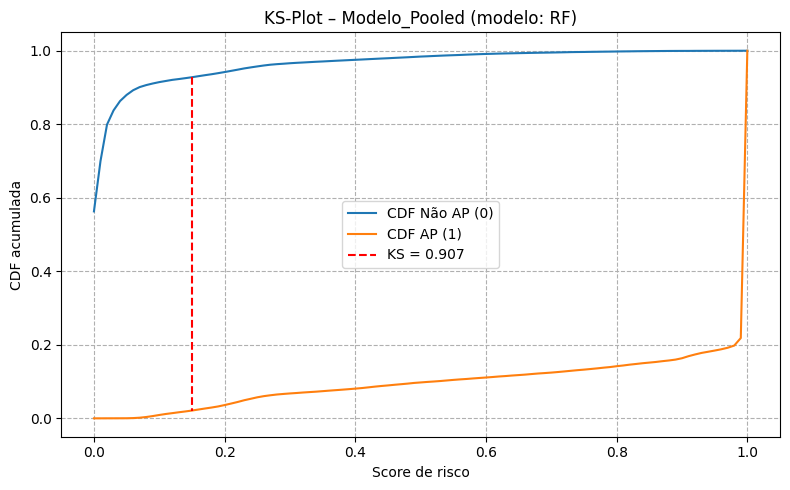


🕒 [7.2.4] Taxa de default ao longo do tempo (por ano)...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/taxa_default_ano_cg_pronampe_pooled.png


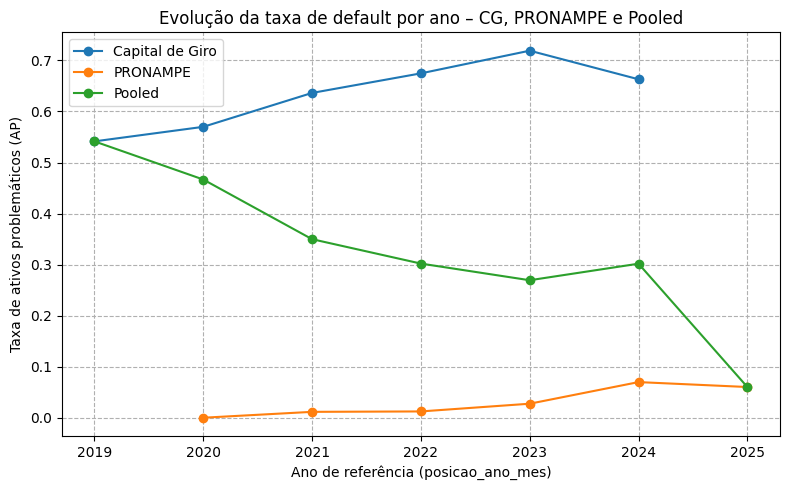


🧬 [7.2.5] Comparando importâncias SHAP (CG, PRONAMPE, Pooled)...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/scatter_shap_cg_vs_pronampe.png


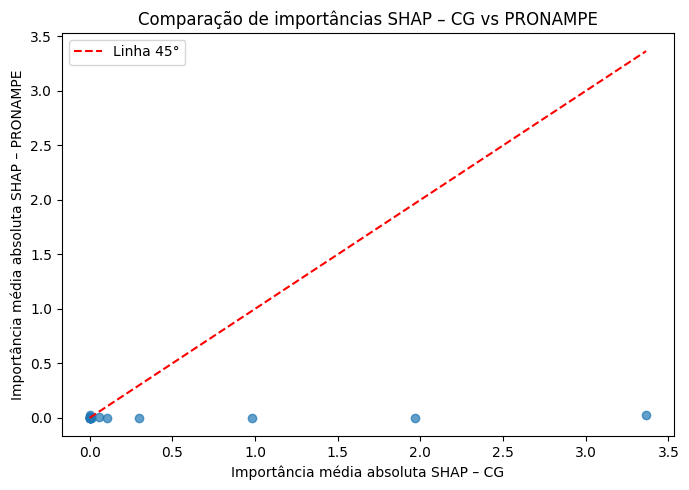

   💾 Tabela de ranking SHAP Top-20 salva em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/shap_top20_ranking_cg_pr_pool.csv
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/tabela_shap_top20_cg_pr_pool.png


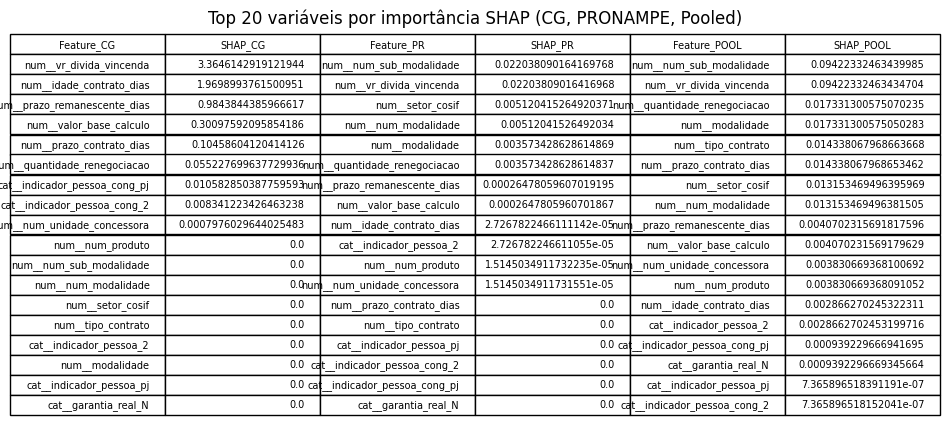


📊 [7.2.6] Gerando radar chart das métricas por experimento...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/radar_chart_metricas_experimentos.png


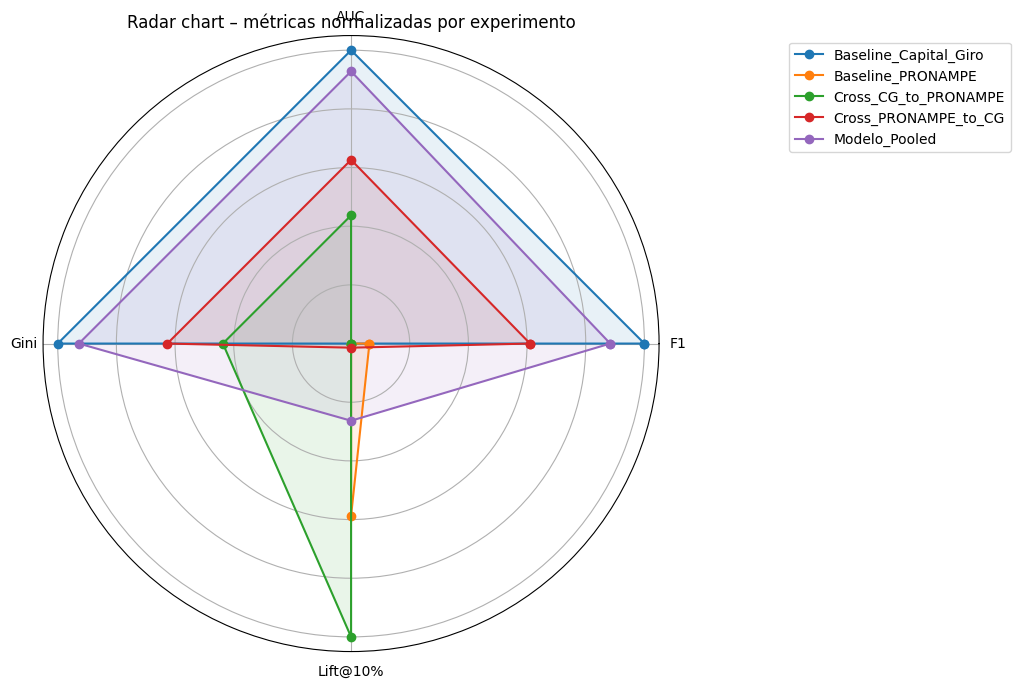


🎯 [7.2.7] Ganho de Lift@10% do modelo Pooled em relação aos baselines...
   💾 Gráfico salvo em: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/graficos_avancados/ganho_lift10_pooled_vs_baselines.png


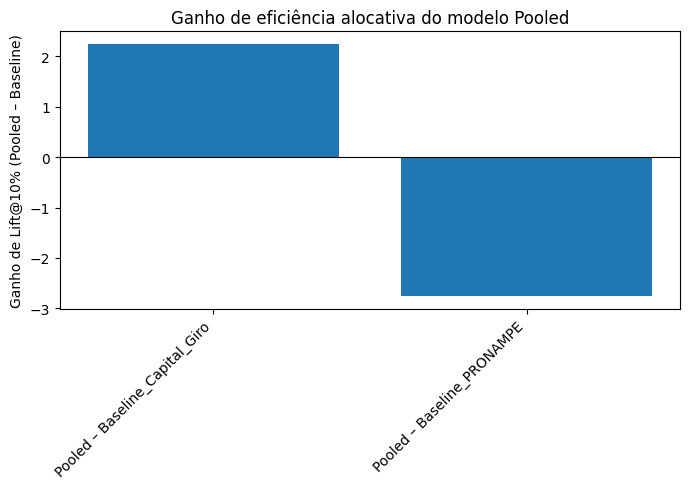


🧩 [7.2.8] Tentativa de gráfico SHAP Waterfall para um contrato (Modelo Pooled)...

🧱 [feature_engineering_sem_vazamento] Iniciando tratamento de features (sem leakage)...
   • Colunas removidas do modelo: 38
   ✅ Feature set preparado sem variáveis de vazamento.
   ⚠ Não foi possível gerar o gráfico SHAP Waterfall.
     Detalhes do erro: waterfall() got an unexpected keyword argument 'feature_names'

✅ ETAPA 7.2 CONCLUÍDA — Visualizações complementares geradas e salvas.



<Figure size 800x600 with 0 Axes>

In [ ]:
# ============================================================
# [ETAPA 7.2] Visualizações complementares (robustez, separação,
#             SHAP comparativo e ganhos do modelo pooled)
# ============================================================

print("\n" + "═"*95)
print("📊  ETAPA 7.2 — VISUALIZAÇÕES COMPLEMENTARES DOS RESULTADOS")
print("═"*95)

from sklearn.metrics import confusion_matrix

# Reutiliza (ou cria) pasta para gráficos avançados
GRAFICOS_AVANC_DIR = os.path.join(MODEL_SAVE_DIR, "graficos_avancados")
os.makedirs(GRAFICOS_AVANC_DIR, exist_ok=True)
print(f"📁 Pasta de gráficos avançados em uso: {GRAFICOS_AVANC_DIR}")

def salvar_fig_72(nome_arquivo):
    """Salva figura atual na pasta de gráficos avançados e exibe."""
    caminho = os.path.join(GRAFICOS_AVANC_DIR, nome_arquivo)
    plt.savefig(caminho, dpi=300, bbox_inches="tight")
    print(f"   💾 Gráfico salvo em: {caminho}")
    plt.show()

# ------------------------------------------------------------
# 7.2.1) Matrizes de confusão dos melhores modelos (experimentos foco)
# ------------------------------------------------------------
print("\n🧾 [7.2.1] Gerando matrizes de confusão (melhores modelos)...")

exp_focus_conf = [
    "Baseline_Capital_Giro",
    "Baseline_PRONAMPE",
    "Cross_CG_to_PRONAMPE",
    "Cross_PRONAMPE_to_CG",
    "Modelo_Pooled"
]

for exp_name in exp_focus_conf:
    best_model = ALL_BEST_MODELS.get(exp_name)
    if best_model is None:
        print(f"   ⚠ Nenhum modelo vencedor encontrado para {exp_name}. Pulando.")
        continue

    detalhe = ALL_DETALHES_MODELOS[exp_name][best_model]
    y_true = detalhe["y_true_test"]
    y_score = detalhe["y_score_test"]

    # Threshold fixo 0.5 (poderia ser calibrado em outra etapa)
    y_pred = (y_score >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Matriz de Confusão – {exp_name}\n(modelo: {best_model})")
    plt.colorbar()
    tick_marks = [0, 1]
    plt.xticks(tick_marks, ["Não AP", "AP"])
    plt.yticks(tick_marks, ["Não AP", "AP"])

    # Anota os valores
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    salvar_fig_72(f"matriz_confusao_{exp_name}.png")

# ------------------------------------------------------------
# 7.2.2) Distribuição dos scores por classe (bons vs problemáticos)
# ------------------------------------------------------------
print("\n📈 [7.2.2] Distribuição de scores por classe (0 = bom, 1 = AP)...")

exp_focus_scores = [
    "Baseline_Capital_Giro",
    "Baseline_PRONAMPE",
    "Modelo_Pooled"
]

for exp_name in exp_focus_scores:
    best_model = ALL_BEST_MODELS.get(exp_name)
    if best_model is None:
        print(f"   ⚠ Nenhum modelo vencedor encontrado para {exp_name}. Pulando.")
        continue

    detalhe = ALL_DETALHES_MODELOS[exp_name][best_model]
    y_true = detalhe["y_true_test"]
    y_score = detalhe["y_score_test"]

    plt.figure(figsize=(8, 5))
    plt.hist(y_score[y_true == 0], bins=30, alpha=0.6, label="Não AP (0)")
    plt.hist(y_score[y_true == 1], bins=30, alpha=0.6, label="AP (1)")
    plt.xlabel("Score de risco (probabilidade predita)")
    plt.ylabel("Frequência")
    plt.title(f"Distribuição dos scores por classe – {exp_name} (modelo: {best_model})")
    plt.legend()
    plt.tight_layout()
    salvar_fig_72(f"distribuicao_scores_por_classe_{exp_name}.png")

# ------------------------------------------------------------
# 7.2.3) KS-Plot (Kolmogorov–Smirnov) – separação por score
# ------------------------------------------------------------
print("\n📊 [7.2.3] Gerando gráficos KS-Plot (CDF dos scores por classe)...")

def ks_plot(y_true, y_score, titulo, nome_arquivo):
    """Gera KS-plot para uma combinação y_true / score."""
    df_tmp = pd.DataFrame({"y": y_true, "score": y_score}).sort_values("score")

    # CDF para cada classe
    df_zeros = df_tmp[df_tmp["y"] == 0].copy()
    df_uns   = df_tmp[df_tmp["y"] == 1].copy()

    df_zeros["cdf"] = np.arange(1, len(df_zeros) + 1) / len(df_zeros)
    df_uns["cdf"]   = np.arange(1, len(df_uns) + 1) / len(df_uns)

    # Alinhamento pelo score
    all_scores = np.sort(df_tmp["score"].unique())
    cdf0 = np.interp(all_scores, df_zeros["score"], df_zeros["cdf"])
    cdf1 = np.interp(all_scores, df_uns["score"], df_uns["cdf"])

    ks_vals = np.abs(cdf1 - cdf0)
    ks_max = ks_vals.max()
    ks_idx = ks_vals.argmax()
    ks_score = all_scores[ks_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(all_scores, cdf0, label="CDF Não AP (0)")
    plt.plot(all_scores, cdf1, label="CDF AP (1)")
    plt.vlines(ks_score, cdf0[ks_idx], cdf1[ks_idx], linestyles="dashed", color="red",
               label=f"KS = {ks_max:.3f}")
    plt.xlabel("Score de risco")
    plt.ylabel("CDF acumulada")
    plt.title(titulo)
    plt.legend()
    plt.grid(True, linestyle="--")
    plt.tight_layout()
    salvar_fig_72(nome_arquivo)

for exp_name in exp_focus_scores:
    best_model = ALL_BEST_MODELS.get(exp_name)
    if best_model is None:
        continue
    detalhe = ALL_DETALHES_MODELOS[exp_name][best_model]
    y_true = detalhe["y_true_test"]
    y_score = detalhe["y_score_test"]

    ks_plot(
        y_true,
        y_score,
        f"KS-Plot – {exp_name} (modelo: {best_model})",
        f"ks_plot_{exp_name}.png"
    )

# ------------------------------------------------------------
# 7.2.4) Drift da taxa de default ao longo do tempo (CG, PRONAMPE, Pooled)
# ------------------------------------------------------------
print("\n🕒 [7.2.4] Taxa de default ao longo do tempo (por ano)...")

def taxa_default_por_ano(df, nome_carteira):
    df = df.copy()
    df["ano"] = df["posicao_ano_mes"].dt.year
    taxas = df.groupby("ano")["ativo_problematico"].mean().reset_index()
    return taxas

plt.figure(figsize=(8, 5))
taxa_cg = taxa_default_por_ano(df_cg, "CG")
taxa_pr = taxa_default_por_ano(df_pronampe, "PRONAMPE")
taxa_pool = taxa_default_por_ano(df_pooled, "Pooled")

plt.plot(taxa_cg["ano"], taxa_cg["ativo_problematico"], marker="o", label="Capital de Giro")
plt.plot(taxa_pr["ano"], taxa_pr["ativo_problematico"], marker="o", label="PRONAMPE")
plt.plot(taxa_pool["ano"], taxa_pool["ativo_problematico"], marker="o", label="Pooled")
plt.xlabel("Ano de referência (posicao_ano_mes)")
plt.ylabel("Taxa de ativos problemáticos (AP)")
plt.title("Evolução da taxa de default por ano – CG, PRONAMPE e Pooled")
plt.legend()
plt.grid(True, linestyle="--")
plt.tight_layout()
salvar_fig_72("taxa_default_ano_cg_pronampe_pooled.png")

# ------------------------------------------------------------
# 7.2.5) Comparação SHAP CG × PR × Pooled (scatter + ranking)
# ------------------------------------------------------------
print("\n🧬 [7.2.5] Comparando importâncias SHAP (CG, PRONAMPE, Pooled)...")

def load_shap_arrays(nome_exp):
    shap_vals = np.load(
        os.path.join(SHAP_SAVE_DIR, f"shap_values_{nome_exp}.npy"),
        allow_pickle=True
    )
    feat_names = np.load(
        os.path.join(SHAP_SAVE_DIR, f"feature_names_{nome_exp}.npy"),
        allow_pickle=True
    )

    # Importância média absoluta
    if isinstance(shap_vals, list) or (hasattr(shap_vals, "dtype") and shap_vals.dtype == "object"):
        try:
            shap_vals = shap_vals[1]
        except Exception:
            shap_vals = shap_vals[0]

    imp_raw = np.abs(shap_vals).mean(axis=0).flatten()
    feat_list = [str(x) for x in feat_names.flatten().tolist()]
    imp = np.array(imp_raw).astype(float).tolist()
    return imp, feat_list

imp_cg, feat_cg = load_shap_arrays("Baseline_Capital_Giro")
imp_pr, feat_pr = load_shap_arrays("Baseline_PRONAMPE")
imp_pool, feat_pool = load_shap_arrays("Modelo_Pooled")

min_len = min(len(imp_cg), len(imp_pr), len(imp_pool))

df_shap = pd.DataFrame({
    "Feature": feat_pool[:min_len],
    "SHAP_CG": imp_cg[:min_len],
    "SHAP_PR": imp_pr[:min_len],
    "SHAP_POOL": imp_pool[:min_len]
})

# Scatter CG vs PR
plt.figure(figsize=(7, 5))
plt.scatter(df_shap["SHAP_CG"], df_shap["SHAP_PR"], alpha=0.7)
max_val = max(df_shap["SHAP_CG"].max(), df_shap["SHAP_PR"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--", color="red", label="Linha 45°")
plt.xlabel("Importância média absoluta SHAP – CG")
plt.ylabel("Importância média absoluta SHAP – PRONAMPE")
plt.title("Comparação de importâncias SHAP – CG vs PRONAMPE")
plt.legend()
plt.tight_layout()
salvar_fig_72("scatter_shap_cg_vs_pronampe.png")

# Ranking side-by-side (Top 20 por carteira)
top_n = 20
top_cg = df_shap.sort_values("SHAP_CG", ascending=False).head(top_n)[["Feature", "SHAP_CG"]].reset_index(drop=True)
top_pr = df_shap.sort_values("SHAP_PR", ascending=False).head(top_n)[["Feature", "SHAP_PR"]].reset_index(drop=True)
top_pool = df_shap.sort_values("SHAP_POOL", ascending=False).head(top_n)[["Feature", "SHAP_POOL"]].reset_index(drop=True)

df_rank = pd.concat([
    top_cg.rename(columns={"Feature": "Feature_CG"}),
    top_pr.rename(columns={"Feature": "Feature_PR"}),
    top_pool.rename(columns={"Feature": "Feature_POOL"})
], axis=1)

rank_path = os.path.join(MODEL_SAVE_DIR, "shap_top20_ranking_cg_pr_pool.csv")
df_rank.to_csv(rank_path, index=False)
print(f"   💾 Tabela de ranking SHAP Top-{top_n} salva em: {rank_path}")

# Opcional: exibir em forma de tabela gráfica simples
plt.figure(figsize=(12, 5))
plt.axis("off")
tbl = plt.table(
    cellText=df_rank.values,
    colLabels=df_rank.columns,
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
tbl.scale(1, 1.2)
plt.title(f"Top {top_n} variáveis por importância SHAP (CG, PRONAMPE, Pooled)")
salvar_fig_72("tabela_shap_top20_cg_pr_pool.png")

# ------------------------------------------------------------
# 7.2.6) Radar chart das métricas (F1, AUC, Gini, Lift@10%)
# ------------------------------------------------------------
print("\n📊 [7.2.6] Gerando radar chart das métricas por experimento...")

metricas = ["F1", "AUC", "Gini", "Lift@10%"]
n_metrics = len(metricas)

# Normaliza métricas entre 0 e 1 para comparabilidade
df_radar = df_best[["Experimento"] + metricas].set_index("Experimento").copy()
df_radar_norm = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min() + 1e-9)

angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # fecha o círculo

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for exp_name, row in df_radar_norm.iterrows():
    values = row.values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, marker="o", label=exp_name)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metricas)
ax.set_yticklabels([])
plt.title("Radar chart – métricas normalizadas por experimento")
plt.legend(bbox_to_anchor=(1.2, 1.0), loc="upper left")
salvar_fig_72("radar_chart_metricas_experimentos.png")

# ------------------------------------------------------------
# 7.2.7) Ganho de Lift do modelo Pooled vs Baselines
# ------------------------------------------------------------
print("\n🎯 [7.2.7] Ganho de Lift@10% do modelo Pooled em relação aos baselines...")

df_eff_copy = df_eff.copy()

lift_pool = df_eff_copy.query("Experimento == 'Modelo_Pooled'")["Lift@10%"]
if not lift_pool.empty:
    lift_pool_val = float(lift_pool.iloc[0])
    comp_exps = ["Baseline_Capital_Giro", "Baseline_PRONAMPE"]
    ganhos = []
    labels = []

    for exp in comp_exps:
        lift_exp = df_eff_copy.query("Experimento == @exp")["Lift@10%"]
        if lift_exp.empty:
            continue
        lift_exp_val = float(lift_exp.iloc[0])
        ganhos.append(lift_pool_val - lift_exp_val)
        labels.append(f"Pooled – {exp}")

    if ganhos:
        plt.figure(figsize=(7, 5))
        plt.bar(labels, ganhos)
        plt.axhline(0, color="black", linewidth=0.8)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Ganho de Lift@10% (Pooled – Baseline)")
        plt.title("Ganho de eficiência alocativa do modelo Pooled")
        plt.tight_layout()
        salvar_fig_72("ganho_lift10_pooled_vs_baselines.png")
    else:
        print("   ⚠ Não foi possível calcular ganhos de Lift (faltam baselines).")
else:
    print("   ⚠ Lift do modelo Pooled não encontrado em df_eff.")

# ------------------------------------------------------------
# 7.2.8) Waterfall SHAP para um contrato representativo – Modelo Pooled
# ------------------------------------------------------------
print("\n🧩 [7.2.8] Tentativa de gráfico SHAP Waterfall para um contrato (Modelo Pooled)...")

try:
    # Reaproveita função já usada antes (se não existir, define rapidamente)
    def extrai_componentes_pipeline_local(pipeline_obj):
        steps = list(pipeline_obj.named_steps.items())
        preproc_name, preproc_obj = steps[0]
        model_name, model_obj = steps[1]
        return preproc_obj, model_obj, model_name

    best_pool_model = ALL_BEST_MODELS.get("Modelo_Pooled")
    pipeline_pool = ALL_DETALHES_MODELOS["Modelo_Pooled"][best_pool_model]["Pipeline"]
    preproc_pool, model_pool, _ = extrai_componentes_pipeline_local(pipeline_pool)

    # Escolhe um contrato AP (1) se existir, senão qualquer um
    df_exemplo = df_pooled.copy()
    df_exemplo_ap = df_exemplo[df_exemplo["ativo_problematico"] == 1]
    if not df_exemplo_ap.empty:
        df_exemplo = df_exemplo_ap
    df_exemplo = df_exemplo.sample(1, random_state=SEED)

    X_exemplo_full = feature_engineering_sem_vazamento(df_exemplo)
    X_exemplo = X_exemplo_full.drop(columns=["ativo_problematico"], errors="ignore")
    X_exemplo_tr = preproc_pool.transform(X_exemplo)
    feat_names_pool = preproc_pool.get_feature_names_out()

    explainer_pool = shap.TreeExplainer(model_pool)
    shap_vals_ex = explainer_pool.shap_values(X_exemplo_tr)

    # Trata binário
    if isinstance(shap_vals_ex, list) or (hasattr(shap_vals_ex, "dtype") and shap_vals_ex.dtype == "object"):
        try:
            shap_vals_ex = shap_vals_ex[1]
        except Exception:
            shap_vals_ex = shap_vals_ex[0]

    shap_vals_ex_row = shap_vals_ex[0]
    base_value = explainer_pool.expected_value[1] if isinstance(explainer_pool.expected_value, (list, np.ndarray)) else explainer_pool.expected_value

    plt.figure(figsize=(8, 6))
    shap.waterfall_plot = getattr(shap, "waterfall_plot", getattr(shap.plots, "waterfall", None))
    shap.waterfall_plot(base_value, shap_vals_ex_row, feature_names=feat_names_pool, max_display=15, show=False)
    plt.title("SHAP Waterfall – Exemplo de contrato (Modelo Pooled)")
    plt.tight_layout()
    salvar_fig_72("shap_waterfall_exemplo_modelo_pooled.png")

except Exception as e:
    print("   ⚠ Não foi possível gerar o gráfico SHAP Waterfall.")
    print("     Detalhes do erro:", e)

print("\n✅ ETAPA 7.2 CONCLUÍDA — Visualizações complementares geradas e salvas.\n")


In [ ]:
# ============================================================
# [ETAPA 8.0] RELATÓRIO FINAL EM PDF (PROFISSIONAL) — TABELAS + GRÁFICOS
# Objetivo:
#   • Gerar um PDF com visual profissional, contendo:
#       - Capa + parâmetros de execução
#       - Melhores modelos (df_best)
#       - Resultados consolidados (df_final_results)
#       - Eficiência (df_eff)
#       - Robustez estatística (df_pvals)
#       - Decis (arquivos decile_analysis_*.csv se existirem)
#       - TODOS os gráficos salvos em graficos/ e graficos_avancados/
# Saída:
#   • PDF em MODEL_SAVE_DIR
# ============================================================

# 0) Dependências
try:
    from reportlab.lib.pagesizes import A4
    from reportlab.platypus import (
        SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
        PageBreak, Image, KeepTogether
    )
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib import colors
    from reportlab.lib.units import cm
except ImportError:
    !pip -q install reportlab
    from reportlab.lib.pagesizes import A4
    from reportlab.platypus import (
        SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
        PageBreak, Image, KeepTogether
    )
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib import colors
    from reportlab.lib.units import cm

import os
import glob
from datetime import datetime

# 1) Checagens mínimas (ajuste conforme seu pipeline)
required_vars = ["MODEL_SAVE_DIR", "MODE_RUN", "SEED", "CG_CUTOFF", "PRONAMPE_CUTOFF", "GLOBAL_CUTOFF"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Variáveis ausentes no ambiente: {missing}")

# Tabelas esperadas (se não existir, a gente pula a seção ao invés de quebrar)
HAS_DF_BEST = ("df_best" in globals()) and (df_best is not None) and (len(df_best) > 0)
HAS_FINAL   = ("df_final_results" in globals()) and (df_final_results is not None) and (len(df_final_results) > 0)
HAS_EFF     = ("df_eff" in globals()) and (df_eff is not None) and (len(df_eff) > 0)
HAS_PVALS   = ("df_pvals" in globals()) and (df_pvals is not None) and (len(df_pvals) > 0)

# 2) Caminhos de gráficos
GRAFICOS_DIR = os.path.join(MODEL_SAVE_DIR, "graficos")
GRAFICOS_AVANC_DIR = os.path.join(MODEL_SAVE_DIR, "graficos_avancados")

pngs_base = sorted(glob.glob(os.path.join(GRAFICOS_DIR, "*.png"))) if os.path.isdir(GRAFICOS_DIR) else []
pngs_av   = sorted(glob.glob(os.path.join(GRAFICOS_AVANC_DIR, "*.png"))) if os.path.isdir(GRAFICOS_AVANC_DIR) else []

# 3) Funções utilitárias
def _fmt(x):
    try:
        if isinstance(x, float):
            return f"{x:.4f}"
    except Exception:
        pass
    return str(x)

def df_to_table(df, max_rows=40, col_widths=None, header_bg=colors.HexColor("#0B3D91")):
    """Converte DF para Table do ReportLab (com truncamento)."""
    dfx = df.copy()
    if len(dfx) > max_rows:
        dfx = dfx.head(max_rows)

    data = [dfx.columns.tolist()] + dfx.values.tolist()
    data = [[_fmt(v) for v in row] for row in data]

    t = Table(data, colWidths=col_widths, repeatRows=1)
    t.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), header_bg),
        ("TEXTCOLOR", (0,0), (-1,0), colors.white),
        ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
        ("FONTSIZE", (0,0), (-1,0), 9),
        ("FONTSIZE", (0,1), (-1,-1), 8),
        ("GRID", (0,0), (-1,-1), 0.25, colors.grey),
        ("ROWBACKGROUNDS", (0,1), (-1,-1), [colors.whitesmoke, colors.lightgrey]),
        ("VALIGN", (0,0), (-1,-1), "MIDDLE"),
        ("TOPPADDING", (0,0), (-1,-1), 4),
        ("BOTTOMPADDING", (0,0), (-1,-1), 4),
    ]))
    return t, (len(df) > max_rows)

def add_fig(path, caption, max_w_cm=17.5, max_h_cm=22.0):
    """Insere figura mantendo proporção, com legenda."""
    img = Image(path)
    img.drawWidth, img.drawHeight = img.imageWidth, img.imageHeight

    max_w = max_w_cm * cm
    max_h = max_h_cm * cm
    scale = min(max_w / img.drawWidth, max_h / img.drawHeight)
    img.drawWidth *= scale
    img.drawHeight *= scale

    block = KeepTogether([
        Paragraph(f"<b>{caption}</b>", styles["Cap"]),
        Spacer(1, 6),
        img,
        Spacer(1, 12)
    ])
    return block

# Cabeçalho/rodapé com numeração
def _header_footer(canvas, doc):
    canvas.saveState()
    canvas.setFont("Helvetica", 8)
    canvas.setFillColor(colors.grey)
    canvas.drawString(1.3*cm, 1.0*cm, "Relatório automático — Pipeline de Modelagem Preditiva (CG vs PRONAMPE)")
    canvas.drawRightString(20.0*cm, 1.0*cm, f"Página {doc.page}")
    canvas.restoreState()

# 4) Config do PDF
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
pdf_path = os.path.join(MODEL_SAVE_DIR, f"Relatorio_Final_Pipeline_{timestamp}.pdf")

doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=1.3*cm, leftMargin=1.3*cm,
    topMargin=1.2*cm, bottomMargin=1.2*cm
)

styles = getSampleStyleSheet()
styles.add(ParagraphStyle(name="TitleX", fontSize=18, leading=22, spaceAfter=10))
styles.add(ParagraphStyle(name="H1X", fontSize=13, leading=16, spaceBefore=10, spaceAfter=6))
styles.add(ParagraphStyle(name="H2X", fontSize=11, leading=14, spaceBefore=8, spaceAfter=5))
styles.add(ParagraphStyle(name="SmallX", fontSize=9, leading=11))
styles.add(ParagraphStyle(name="Cap", fontSize=9, leading=11, textColor=colors.black, spaceAfter=4))

story = []

# 5) CAPA
story.append(Paragraph("RELATÓRIO FINAL — RESULTADOS DO PIPELINE", styles["TitleX"]))
story.append(Paragraph("Dissertação: Modelagem Preditiva do Risco de Crédito com Machine Learning (CG vs PRONAMPE)", styles["SmallX"]))
story.append(Paragraph("Autor: Alessandro Moreira dos Santos | Orientador: Prof. Dr. Roberto Miranda Pimentel Fully", styles["SmallX"]))
story.append(Paragraph(f"Gerado em: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}", styles["SmallX"]))
story.append(Spacer(1, 12))

# Parâmetros
params_lines = [
    f"<b>MODE_RUN</b>: {MODE_RUN}",
    f"<b>SEED</b>: {SEED}",
    f"<b>CG_CUTOFF</b>: {CG_CUTOFF.strftime('%Y-%m-%d')}",
    f"<b>PRONAMPE_CUTOFF</b>: {PRONAMPE_CUTOFF.strftime('%Y-%m-%d')}",
    f"<b>GLOBAL_CUTOFF</b>: {GLOBAL_CUTOFF.strftime('%Y-%m-%d')}",
]
if "MAX_SAMPLES" in globals(): params_lines.append(f"<b>MAX_SAMPLES</b>: {MAX_SAMPLES:,}")
if "N_FOLDS" in globals():     params_lines.append(f"<b>N_FOLDS</b>: {N_FOLDS}")
if "MAX_SAMPLE_SHAP" in globals(): params_lines.append(f"<b>MAX_SAMPLE_SHAP</b>: {MAX_SAMPLE_SHAP:,}")

story.append(Paragraph("Parâmetros de Execução", styles["H1X"]))
story.append(Paragraph(" | ".join(params_lines), styles["SmallX"]))
story.append(Spacer(1, 10))

# Sumário simples
story.append(Paragraph("Conteúdo", styles["H1X"]))
toc_lines = [
    "1) Melhores modelos por experimento (df_best)",
    "2) Resultados consolidados OOT (df_final_results)",
    "3) Eficiência alocativa (df_eff: Gini e Lift@10%)",
    "4) Robustez estatística (df_pvals: KS, AD, Wilcoxon, Mann–Whitney + FDR)",
    "5) Decile Analysis (arquivos CSV)",
    "6) Figuras — gráficos principais (graficos/)",
    "7) Figuras — gráficos avançados (graficos_avancados/)",
]
story.append(Paragraph("<br/>".join(toc_lines), styles["SmallX"]))
story.append(PageBreak())

# 6) SEÇÃO 1 — df_best
story.append(Paragraph("1) Melhores modelos por experimento (df_best)", styles["H1X"]))
if HAS_DF_BEST:
    cols = [c for c in ["Experimento","Modelo_Nome","F1","AUC","Recall","Precisao","Acurácia","Gini","Lift@10%"] if c in df_best.columns]
    t, trunc = df_to_table(df_best[cols], max_rows=25, header_bg=colors.HexColor("#0B3D91"))
    story.append(t)
    if trunc:
        story.append(Spacer(1, 6))
        story.append(Paragraph(f"<i>Obs.: tabela truncada (mostrando 25 linhas; total real = {len(df_best)}).</i>", styles["SmallX"]))
else:
    story.append(Paragraph("Tabela df_best não disponível no ambiente (ou vazia).", styles["SmallX"]))
story.append(PageBreak())

# 7) SEÇÃO 2 — df_final_results
story.append(Paragraph("2) Resultados consolidados OOT (df_final_results)", styles["H1X"]))
if HAS_FINAL:
    cols = [c for c in ["Experimento","Modelo_Nome","AUC","F1","Recall","Precisao","Acurácia"] if c in df_final_results.columns]
    t, trunc = df_to_table(df_final_results[cols].sort_values(["Experimento","F1"], ascending=[True,False]), max_rows=35,
                           header_bg=colors.HexColor("#2E7D32"))
    story.append(t)
    if trunc:
        story.append(Spacer(1, 6))
        story.append(Paragraph(f"<i>Obs.: tabela truncada (35 linhas; total real = {len(df_final_results)}).</i>", styles["SmallX"]))
else:
    story.append(Paragraph("Tabela df_final_results não disponível no ambiente (ou vazia).", styles["SmallX"]))
story.append(PageBreak())

# 8) SEÇÃO 3 — df_eff
story.append(Paragraph("3) Eficiência alocativa (Gini e Lift@10%) — df_eff", styles["H1X"]))
if HAS_EFF:
    t, trunc = df_to_table(df_eff, max_rows=30, header_bg=colors.HexColor("#6A1B9A"))
    story.append(t)
    if trunc:
        story.append(Spacer(1, 6))
        story.append(Paragraph(f"<i>Obs.: tabela truncada (30 linhas; total real = {len(df_eff)}).</i>", styles["SmallX"]))
else:
    story.append(Paragraph("Tabela df_eff não disponível no ambiente (ou vazia).", styles["SmallX"]))
story.append(PageBreak())

# 9) SEÇÃO 4 — df_pvals
story.append(Paragraph("4) Robustez estatística — df_pvals (testes + FDR)", styles["H1X"]))
if HAS_PVALS:
    # seleciona colunas mais úteis (se existirem)
    pref = ["A_vs_B","KS_p","KS_p_FDR","AD_p","AD_p_FDR","Wilcoxon_p","Wilcoxon_p_FDR","MannWhitney_p","MannWhitney_p_FDR"]
    cols = [c for c in pref if c in df_pvals.columns]
    t, trunc = df_to_table(df_pvals[cols], max_rows=25, header_bg=colors.HexColor("#C62828"))
    story.append(t)
    if trunc:
        story.append(Spacer(1, 6))
        story.append(Paragraph(f"<i>Obs.: tabela truncada (25 linhas; total real = {len(df_pvals)}).</i>", styles["SmallX"]))
else:
    story.append(Paragraph("Tabela df_pvals não disponível no ambiente (ou vazia).", styles["SmallX"]))
story.append(PageBreak())

# 10) SEÇÃO 5 — Decile Analysis (CSV)
story.append(Paragraph("5) Decile Analysis (arquivos CSV salvos)", styles["H1X"]))
deciles = sorted(glob.glob(os.path.join(MODEL_SAVE_DIR, "decile_analysis_*.csv")))
if deciles:
    story.append(Paragraph("Arquivos encontrados:", styles["SmallX"]))
    story.append(Paragraph("<br/>".join([os.path.basename(p) for p in deciles]), styles["SmallX"]))
else:
    story.append(Paragraph("Nenhum arquivo decile_analysis_*.csv encontrado.", styles["SmallX"]))
story.append(PageBreak())

# 11) SEÇÃO 6 — Figuras principais
story.append(Paragraph("6) Figuras — gráficos principais (graficos/)", styles["H1X"]))
if pngs_base:
    for i, p in enumerate(pngs_base, start=1):
        cap = f"Figura {i} — {os.path.basename(p)}"
        story.append(add_fig(p, cap))
else:
    story.append(Paragraph("Nenhuma figura PNG encontrada em graficos/.", styles["SmallX"]))
story.append(PageBreak())

# 12) SEÇÃO 7 — Figuras avançadas
story.append(Paragraph("7) Figuras — gráficos avançados (graficos_avancados/)", styles["H1X"]))
if pngs_av:
    for j, p in enumerate(pngs_av, start=1):
        cap = f"Figura A{j} — {os.path.basename(p)}"
        story.append(add_fig(p, cap))
else:
    story.append(Paragraph("Nenhuma figura PNG encontrada em graficos_avancados/.", styles["SmallX"]))

# 13) Geração
doc.build(story, onFirstPage=_header_footer, onLaterPages=_header_footer)

print("\n✅ RELATÓRIO FINAL gerado com sucesso!")
print(f"📄 Caminho do PDF: {pdf_path}")
print(f"📌 Figuras incluídas: {len(pngs_base)} (principais) + {len(pngs_av)} (avançadas)")



✅ RELATÓRIO FINAL gerado com sucesso!
📄 Caminho do PDF: /content/drive/MyDrive/Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Resultados_Artigo SBFin_XXVI Encontro Brasileiro de Finanças/Relatorio_Final_Pipeline_20260312_032444.pdf
📌 Figuras incluídas: 6 (principais) + 28 (avançadas)
